In [1]:
import sys
import torch
import open_clip

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: D:\Program Files\anaconda\python.exe
PyTorch: 2.12.0.dev20260415+cu130
CUDA: True
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [2]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [5]:
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)

    print("GPU:", props.name)
    print(f"VRAM: {props.total_memory / 1024**3:.2f} GB")

GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
VRAM: 11.94 GB


In [9]:
import clip
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

MODEL_NAME = "ViT-B/32"
MODEL_PATH = r"../models/ViT-B-32.pt"

model, preprocess = clip.load(
    MODEL_PATH,
    device=device,
    jit=False
)

model.eval()

print("CLIP model loaded successfully.")
print("Model:", MODEL_NAME)
print("Device:", next(model.parameters()).device)

CLIP model loaded successfully.
Model: ViT-B/32
Device: cuda:0


In [11]:
texts = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of an airplane"
]

text_tokens = clip.tokenize(texts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)

text_features = text_features / text_features.norm(
    dim=-1,
    keepdim=True
)

print("Tokens:", text_tokens.shape)
print("Text features:", text_features.shape)
print("Device:", text_features.device)
print("Norm:", text_features[0].norm())

Tokens: torch.Size([3, 77])
Text features: torch.Size([3, 512])
Device: cuda:0
Norm: tensor(1., device='cuda:0', dtype=torch.float16)


In [13]:
from pathlib import Path

DATA_DIR = Path(r"D:\Sept\工作\260826-clip-zs-lp-cifar\data")

cifar_archive = DATA_DIR / "cifar-10-python.tar.gz"

print("Data directory:", DATA_DIR)
print("Archive path:", cifar_archive)
print("Archive exists:", cifar_archive.exists())

if cifar_archive.exists():
    print(
        "Archive size:",
        round(cifar_archive.stat().st_size / 1024 / 1024, 2),
        "MB"
    )

Data directory: D:\Sept\工作\260826-clip-zs-lp-cifar\data
Archive path: D:\Sept\工作\260826-clip-zs-lp-cifar\data\cifar-10-python.tar.gz
Archive exists: True
Archive size: 162.6 MB


In [14]:
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

test_dataset = CIFAR10(
    root=DATA_DIR,
    train=False,
    transform=preprocess,
    download=True,
)

BATCH_SIZE = 256

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("Test images:", len(test_dataset))
print("Number of batches:", len(test_loader))

Test images: 10000
Number of batches: 40


D:\Program Files\anaconda\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [15]:
# --------------------------------------------------
# Experiment 1
# Zero-shot baseline: class name only
# --------------------------------------------------

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

# Baseline prompt:
# only the raw class name, no template
baseline_texts = class_names

print("Baseline prompts:")
for i, text in enumerate(baseline_texts):
    print(f"{i}: {text}")


# --------------------------------------------------
# Tokenize
# --------------------------------------------------

text_tokens = clip.tokenize(
    baseline_texts
).to(device)


# --------------------------------------------------
# Text encoder
# --------------------------------------------------

with torch.no_grad():
    text_features = model.encode_text(
        text_tokens
    )


# --------------------------------------------------
# L2 normalization
# --------------------------------------------------

text_features = (
    text_features
    / text_features.norm(
        dim=-1,
        keepdim=True
    )
)


# --------------------------------------------------
# Check
# --------------------------------------------------

print()
print("Text tokens:", text_tokens.shape)
print("Text features:", text_features.shape)
print("Device:", text_features.device)

print(
    "Embedding norms:",
    text_features.norm(dim=-1)
)

Baseline prompts:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck

Text tokens: torch.Size([10, 77])
Text features: torch.Size([10, 512])
Device: cuda:0
Embedding norms: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        0.9995], device='cuda:0', dtype=torch.float16)


In [16]:
# --------------------------------------------------
# Experiment 1
# Zero-shot baseline evaluation
# Prompt: class name only
# --------------------------------------------------

num_classes = len(class_names)

# --------------------------------------------------
# Statistics containers
# --------------------------------------------------

total_correct = 0
total_samples = 0

correct_per_class = torch.zeros(
    num_classes,
    dtype=torch.long
)

total_per_class = torch.zeros(
    num_classes,
    dtype=torch.long
)

confusion_matrix = torch.zeros(
    (num_classes, num_classes),
    dtype=torch.long
)


# --------------------------------------------------
# Evaluation mode
# --------------------------------------------------

model.eval()

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        # ------------------------------------------
        # Move batch to GPU
        # ------------------------------------------

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # ------------------------------------------
        # CLIP image encoder
        # ------------------------------------------

        image_features = model.encode_image(
            images
        )


        # ------------------------------------------
        # L2 normalize image embeddings
        # ------------------------------------------

        image_features = (
            image_features
            / image_features.norm(
                dim=-1,
                keepdim=True
            )
        )


        # ------------------------------------------
        # Cosine similarity
        #
        # image_features:
        #   [batch_size, 512]
        #
        # text_features.T:
        #   [512, 10]
        #
        # similarities:
        #   [batch_size, 10]
        # ------------------------------------------

        similarities = (
            image_features
            @ text_features.T
        )


        # ------------------------------------------
        # Top-1 prediction
        # ------------------------------------------

        predictions = similarities.argmax(
            dim=1
        )


        # ------------------------------------------
        # Overall accuracy
        # ------------------------------------------

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)


        # ------------------------------------------
        # Move small vectors to CPU
        # ------------------------------------------

        labels_cpu = labels.cpu()
        predictions_cpu = predictions.cpu()


        # ------------------------------------------
        # Per-class statistics
        # ------------------------------------------

        for class_idx in range(num_classes):

            class_mask = (
                labels_cpu == class_idx
            )

            total_per_class[class_idx] += (
                class_mask.sum()
            )

            correct_per_class[class_idx] += (
                predictions_cpu[class_mask]
                == class_idx
            ).sum()


        # ------------------------------------------
        # Confusion matrix
        #
        # Row    = true class
        # Column = predicted class
        # ------------------------------------------

        for true_label, pred_label in zip(
            labels_cpu,
            predictions_cpu
        ):

            confusion_matrix[
                true_label.item(),
                pred_label.item()
            ] += 1


        # ------------------------------------------
        # Progress
        # ------------------------------------------

        if (
            (batch_idx + 1) % 10 == 0
            or
            (batch_idx + 1) == len(test_loader)
        ):

            running_accuracy = (
                total_correct
                / total_samples
            )

            print(
                f"Batch {batch_idx + 1:>2}/"
                f"{len(test_loader)}"
                f" | samples={total_samples:>5}"
                f" | accuracy={running_accuracy:.4f}"
            )


# --------------------------------------------------
# Final overall accuracy
# --------------------------------------------------

overall_accuracy = (
    total_correct
    / total_samples
)


# --------------------------------------------------
# Per-class accuracy
# --------------------------------------------------

per_class_accuracy = (
    correct_per_class.float()
    / total_per_class.float()
)


# --------------------------------------------------
# Print results
# --------------------------------------------------

print()
print("=" * 50)
print("Zero-shot baseline complete")
print("=" * 50)

print(
    f"Overall accuracy: "
    f"{overall_accuracy:.4f}"
)

print(
    f"Overall accuracy: "
    f"{overall_accuracy * 100:.2f}%"
)

print()
print("Per-class accuracy:")

for class_name, accuracy in zip(
    class_names,
    per_class_accuracy
):

    print(
        f"{class_name:>10}: "
        f"{accuracy.item() * 100:6.2f}%"
    )

print()
print(
    "Total evaluated images:",
    total_samples
)

print(
    "Samples per class:",
    total_per_class.tolist()
)

Batch 10/40 | samples= 2560 | accuracy=0.8797
Batch 20/40 | samples= 5120 | accuracy=0.8787
Batch 30/40 | samples= 7680 | accuracy=0.8760
Batch 40/40 | samples=10000 | accuracy=0.8738

Zero-shot baseline complete
Overall accuracy: 0.8738
Overall accuracy: 87.38%

Per-class accuracy:
  airplane:  81.30%
automobile:  89.90%
      bird:  91.70%
       cat:  79.20%
      deer:  82.20%
       dog:  85.20%
      frog:  77.00%
     horse:  97.10%
      ship:  96.30%
     truck:  93.90%

Total evaluated images: 10000
Samples per class: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


In [17]:
# --------------------------------------------------
# Experiment 1 - Step 2D
# Save zero-shot class-name baseline results
# --------------------------------------------------

import csv


# --------------------------------------------------
# 0. Basic consistency checks
# --------------------------------------------------

assert total_samples == 10000

assert total_per_class.tolist() == [
    1000, 1000, 1000, 1000, 1000,
    1000, 1000, 1000, 1000, 1000
]

assert confusion_matrix.sum().item() == 10000

print("Sanity checks passed.")


# --------------------------------------------------
# 1. Overall accuracy
# --------------------------------------------------

overall_result_path = (
    RESULTS_DIR / "zero_shot_results.csv"
)

with open(
    overall_result_path,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "setting",
        "prompt",
        "accuracy",
        "accuracy_percent",
        "trainable_params",
        "training_cost",
    ])

    writer.writerow([
        "zero-shot",
        "class name",
        overall_accuracy,
        overall_accuracy * 100,
        0,
        "Very low",
    ])


# --------------------------------------------------
# 2. Per-class accuracy
# --------------------------------------------------

per_class_result_path = (
    RESULTS_DIR / "per_class_accuracy.csv"
)

with open(
    per_class_result_path,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "setting",
        "prompt",
        "class",
        "accuracy",
        "accuracy_percent",
        "correct",
        "total",
    ])

    for class_idx, class_name in enumerate(
        class_names
    ):

        writer.writerow([
            "zero-shot",
            "class name",
            class_name,
            per_class_accuracy[class_idx].item(),
            per_class_accuracy[class_idx].item() * 100,
            correct_per_class[class_idx].item(),
            total_per_class[class_idx].item(),
        ])


# --------------------------------------------------
# 3. Raw confusion matrix
# --------------------------------------------------

confusion_matrix_path = (
    RESULTS_DIR
    / "confusion_matrix_zero_shot_class_name.csv"
)

with open(
    confusion_matrix_path,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    # Header:
    # true class in rows
    # predicted class in columns
    writer.writerow(
        ["true\\pred"] + class_names
    )

    for class_idx, class_name in enumerate(
        class_names
    ):

        writer.writerow(
            [class_name]
            + confusion_matrix[
                class_idx
            ].tolist()
        )


# --------------------------------------------------
# 4. Confirm saved files
# --------------------------------------------------

print()
print("Baseline results saved:")

print(
    "1.",
    overall_result_path
)

print(
    "2.",
    per_class_result_path
)

print(
    "3.",
    confusion_matrix_path
)

Sanity checks passed.

Baseline results saved:
1. D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\zero_shot_results.csv
2. D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\per_class_accuracy.csv
3. D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\confusion_matrix_zero_shot_class_name.csv


In [18]:
# --------------------------------------------------
# Experiment 2 - Step 3A
# Prompt Engineering
# Template A: "a photo of a {class}"
# --------------------------------------------------

template_a = "a photo of a {}"

template_a_texts = [
    template_a.format(class_name)
    for class_name in class_names
]


# --------------------------------------------------
# 1. Show prompts
# --------------------------------------------------

print("Template A prompts:")

for i, text in enumerate(template_a_texts):
    print(f"{i}: {text}")


# --------------------------------------------------
# 2. Encode text prompts
# --------------------------------------------------

template_a_tokens = clip.tokenize(
    template_a_texts
).to(device)

with torch.no_grad():

    template_a_text_features = model.encode_text(
        template_a_tokens
    )


# --------------------------------------------------
# 3. L2 normalization
# --------------------------------------------------

template_a_text_features = (
    template_a_text_features
    / template_a_text_features.norm(
        dim=-1,
        keepdim=True
    )
)


print()
print(
    "Text tokens:",
    template_a_tokens.shape
)

print(
    "Text features:",
    template_a_text_features.shape
)

print(
    "Device:",
    template_a_text_features.device
)

print(
    "Embedding norms:",
    template_a_text_features.norm(dim=-1)
)


# --------------------------------------------------
# 4. Statistics containers
# --------------------------------------------------

num_classes = len(class_names)

template_a_total_correct = 0
template_a_total_samples = 0

template_a_correct_per_class = torch.zeros(
    num_classes,
    dtype=torch.long
)

template_a_total_per_class = torch.zeros(
    num_classes,
    dtype=torch.long
)

template_a_confusion_matrix = torch.zeros(
    (num_classes, num_classes),
    dtype=torch.long
)


# --------------------------------------------------
# 5. Zero-shot evaluation
# --------------------------------------------------

model.eval()

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(
        test_loader
    ):

        # Move data to GPU
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # ------------------------------------------
        # Image encoder
        # ------------------------------------------

        image_features = model.encode_image(
            images
        )


        # L2 normalization
        image_features = (
            image_features
            / image_features.norm(
                dim=-1,
                keepdim=True
            )
        )


        # ------------------------------------------
        # Image-text cosine similarity
        # ------------------------------------------

        similarities = (
            image_features
            @ template_a_text_features.T
        )


        predictions = similarities.argmax(
            dim=1
        )


        # ------------------------------------------
        # Overall statistics
        # ------------------------------------------

        template_a_total_correct += (
            predictions == labels
        ).sum().item()

        template_a_total_samples += (
            labels.size(0)
        )


        labels_cpu = labels.cpu()
        predictions_cpu = predictions.cpu()


        # ------------------------------------------
        # Per-class statistics
        # ------------------------------------------

        for class_idx in range(num_classes):

            class_mask = (
                labels_cpu == class_idx
            )

            template_a_total_per_class[
                class_idx
            ] += class_mask.sum()

            template_a_correct_per_class[
                class_idx
            ] += (
                predictions_cpu[class_mask]
                == class_idx
            ).sum()


        # ------------------------------------------
        # Confusion matrix
        # ------------------------------------------

        for true_label, pred_label in zip(
            labels_cpu,
            predictions_cpu
        ):

            template_a_confusion_matrix[
                true_label.item(),
                pred_label.item()
            ] += 1


        # ------------------------------------------
        # Progress
        # ------------------------------------------

        if (
            (batch_idx + 1) % 10 == 0
            or
            (batch_idx + 1) == len(test_loader)
        ):

            running_accuracy = (
                template_a_total_correct
                / template_a_total_samples
            )

            print(
                f"Batch {batch_idx + 1:>2}/"
                f"{len(test_loader)}"
                f" | samples="
                f"{template_a_total_samples:>5}"
                f" | accuracy="
                f"{running_accuracy:.4f}"
            )


# --------------------------------------------------
# 6. Final results
# --------------------------------------------------

template_a_accuracy = (
    template_a_total_correct
    / template_a_total_samples
)

template_a_per_class_accuracy = (
    template_a_correct_per_class.float()
    / template_a_total_per_class.float()
)


print()
print("=" * 60)
print('Prompt Engineering: "a photo of a {class}"')
print("=" * 60)

print(
    f"Overall accuracy: "
    f"{template_a_accuracy:.4f}"
)

print(
    f"Overall accuracy: "
    f"{template_a_accuracy * 100:.2f}%"
)


print()
print("Per-class accuracy:")

for class_name, accuracy in zip(
    class_names,
    template_a_per_class_accuracy
):

    print(
        f"{class_name:>10}: "
        f"{accuracy.item() * 100:6.2f}%"
    )


# --------------------------------------------------
# 7. Compare against baseline
# --------------------------------------------------

accuracy_change = (
    template_a_accuracy
    - overall_accuracy
)

print()
print("=" * 60)
print("Comparison with class-name baseline")
print("=" * 60)

print(
    f"Baseline:    "
    f"{overall_accuracy * 100:.2f}%"
)

print(
    f"Template A:  "
    f"{template_a_accuracy * 100:.2f}%"
)

print(
    f"Difference:  "
    f"{accuracy_change * 100:+.2f} percentage points"
)


print()
print("Per-class changes:")

for class_idx, class_name in enumerate(
    class_names
):

    baseline_acc = (
        per_class_accuracy[class_idx].item()
        * 100
    )

    new_acc = (
        template_a_per_class_accuracy[
            class_idx
        ].item()
        * 100
    )

    change = new_acc - baseline_acc

    print(
        f"{class_name:>10}: "
        f"{baseline_acc:6.2f}%"
        f" -> "
        f"{new_acc:6.2f}%"
        f"  ({change:+6.2f} pp)"
    )

Template A prompts:
0: a photo of a airplane
1: a photo of a automobile
2: a photo of a bird
3: a photo of a cat
4: a photo of a deer
5: a photo of a dog
6: a photo of a frog
7: a photo of a horse
8: a photo of a ship
9: a photo of a truck

Text tokens: torch.Size([10, 77])
Text features: torch.Size([10, 512])
Device: cuda:0
Embedding norms: tensor([1.0000, 1.0000, 0.9995, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        0.9995], device='cuda:0', dtype=torch.float16)
Batch 10/40 | samples= 2560 | accuracy=0.9012
Batch 20/40 | samples= 5120 | accuracy=0.8936
Batch 30/40 | samples= 7680 | accuracy=0.8901
Batch 40/40 | samples=10000 | accuracy=0.8883

Prompt Engineering: "a photo of a {class}"
Overall accuracy: 0.8883
Overall accuracy: 88.83%

Per-class accuracy:
  airplane:  90.20%
automobile:  97.60%
      bird:  88.80%
       cat:  86.20%
      deer:  76.50%
       dog:  88.30%
      frog:  77.50%
     horse:  97.70%
      ship:  95.50%
     truck:  90.00%

Comparison with class

In [19]:
# --------------------------------------------------
# Experiment 2A - Step 3B
# Save Template A results
# Prompt: "a photo of a {class}"
# --------------------------------------------------

import csv


# --------------------------------------------------
# 1. Sanity checks
# --------------------------------------------------

assert template_a_total_samples == 10000

assert template_a_total_per_class.tolist() == [
    1000, 1000, 1000, 1000, 1000,
    1000, 1000, 1000, 1000, 1000
]

assert (
    template_a_confusion_matrix.sum().item()
    == 10000
)

print("Template A sanity checks passed.")


# --------------------------------------------------
# 2. Append overall result
# --------------------------------------------------

overall_result_path = (
    RESULTS_DIR / "zero_shot_results.csv"
)

with open(
    overall_result_path,
    "a",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "zero-shot",
        "a photo of a {}",
        template_a_accuracy,
        template_a_accuracy * 100,
        0,
        "Very low",
    ])


# --------------------------------------------------
# 3. Append per-class results
# --------------------------------------------------

per_class_result_path = (
    RESULTS_DIR / "per_class_accuracy.csv"
)

with open(
    per_class_result_path,
    "a",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    for class_idx, class_name in enumerate(
        class_names
    ):

        writer.writerow([
            "zero-shot",
            "a photo of a {}",
            class_name,
            template_a_per_class_accuracy[
                class_idx
            ].item(),
            template_a_per_class_accuracy[
                class_idx
            ].item() * 100,
            template_a_correct_per_class[
                class_idx
            ].item(),
            template_a_total_per_class[
                class_idx
            ].item(),
        ])


# --------------------------------------------------
# 4. Save Template A confusion matrix
# --------------------------------------------------

template_a_cm_path = (
    RESULTS_DIR
    / "confusion_matrix_zero_shot_template_a.csv"
)

with open(
    template_a_cm_path,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow(
        ["true\\pred"] + class_names
    )

    for class_idx, class_name in enumerate(
        class_names
    ):

        writer.writerow(
            [class_name]
            + template_a_confusion_matrix[
                class_idx
            ].tolist()
        )


# --------------------------------------------------
# 5. Confirmation
# --------------------------------------------------

print()
print("Template A results saved.")

print(
    "Overall results:",
    overall_result_path
)

print(
    "Per-class results:",
    per_class_result_path
)

print(
    "Confusion matrix:",
    template_a_cm_path
)

print()
print(
    f"Baseline accuracy:   "
    f"{overall_accuracy * 100:.2f}%"
)

print(
    f"Template A accuracy: "
    f"{template_a_accuracy * 100:.2f}%"
)

print(
    f"Improvement:         "
    f"{(template_a_accuracy - overall_accuracy) * 100:+.2f} pp"
)

Template A sanity checks passed.

Template A results saved.
Overall results: D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\zero_shot_results.csv
Per-class results: D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\per_class_accuracy.csv
Confusion matrix: D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\confusion_matrix_zero_shot_template_a.csv

Baseline accuracy:   87.38%
Template A accuracy: 88.83%
Improvement:         +1.45 pp


In [20]:
# --------------------------------------------------
# Experiment 2 - Reusable prompt evaluation function
# --------------------------------------------------

def evaluate_zero_shot_prompt(
    template,
    template_name,
    model,
    test_loader,
    class_names,
    device,
):
    """
    Evaluate one prompt template on the full CIFAR-10 test set.

    Example:
        template = "a blurry photo of a {}"
    """

    num_classes = len(class_names)

    # --------------------------------------------------
    # 1. Build prompts
    # --------------------------------------------------

    texts = [
        template.format(class_name)
        for class_name in class_names
    ]

    print("=" * 65)
    print(f"Evaluating: {template_name}")
    print(f'Template: "{template}"')
    print("=" * 65)

    print("\nPrompts:")

    for i, text in enumerate(texts):
        print(f"{i}: {text}")


    # --------------------------------------------------
    # 2. Encode text
    # --------------------------------------------------

    text_tokens = clip.tokenize(
        texts
    ).to(device)

    with torch.no_grad():

        prompt_text_features = model.encode_text(
            text_tokens
        )

    prompt_text_features = (
        prompt_text_features
        / prompt_text_features.norm(
            dim=-1,
            keepdim=True
        )
    )


    # --------------------------------------------------
    # 3. Statistics
    # --------------------------------------------------

    total_correct = 0
    total_samples = 0

    correct_per_class = torch.zeros(
        num_classes,
        dtype=torch.long
    )

    total_per_class = torch.zeros(
        num_classes,
        dtype=torch.long
    )

    confusion_matrix = torch.zeros(
        (num_classes, num_classes),
        dtype=torch.long
    )


    # --------------------------------------------------
    # 4. Full CIFAR-10 evaluation
    # --------------------------------------------------

    model.eval()

    with torch.no_grad():

        for batch_idx, (images, labels) in enumerate(
            test_loader
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            # CLIP image features
            image_features = model.encode_image(
                images
            )

            image_features = (
                image_features
                / image_features.norm(
                    dim=-1,
                    keepdim=True
                )
            )


            # Cosine similarity
            similarities = (
                image_features
                @ prompt_text_features.T
            )

            predictions = similarities.argmax(
                dim=1
            )


            # Overall
            total_correct += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)


            # CPU statistics
            labels_cpu = labels.cpu()
            predictions_cpu = predictions.cpu()


            # Per-class
            for class_idx in range(num_classes):

                class_mask = (
                    labels_cpu == class_idx
                )

                total_per_class[class_idx] += (
                    class_mask.sum()
                )

                correct_per_class[class_idx] += (
                    predictions_cpu[class_mask]
                    == class_idx
                ).sum()


            # Confusion matrix
            for true_label, pred_label in zip(
                labels_cpu,
                predictions_cpu
            ):

                confusion_matrix[
                    true_label.item(),
                    pred_label.item()
                ] += 1


            # Progress
            if (
                (batch_idx + 1) % 10 == 0
                or
                (batch_idx + 1) == len(test_loader)
            ):

                running_accuracy = (
                    total_correct
                    / total_samples
                )

                print(
                    f"Batch {batch_idx + 1:>2}/"
                    f"{len(test_loader)}"
                    f" | samples={total_samples:>5}"
                    f" | accuracy={running_accuracy:.4f}"
                )


    # --------------------------------------------------
    # 5. Final statistics
    # --------------------------------------------------

    accuracy = (
        total_correct
        / total_samples
    )

    per_class_accuracy = (
        correct_per_class.float()
        / total_per_class.float()
    )


    # --------------------------------------------------
    # 6. Sanity checks
    # --------------------------------------------------

    assert total_samples == 10000

    assert total_per_class.tolist() == [
        1000, 1000, 1000, 1000, 1000,
        1000, 1000, 1000, 1000, 1000
    ]

    assert confusion_matrix.sum().item() == 10000


    # --------------------------------------------------
    # 7. Print results
    # --------------------------------------------------

    print()
    print("=" * 65)
    print(f"{template_name} complete")
    print("=" * 65)

    print(
        f"Overall accuracy: "
        f"{accuracy * 100:.2f}%"
    )

    print("\nPer-class accuracy:")

    for class_name, class_accuracy in zip(
        class_names,
        per_class_accuracy
    ):

        print(
            f"{class_name:>10}: "
            f"{class_accuracy.item() * 100:6.2f}%"
        )


    # --------------------------------------------------
    # 8. Return everything we need later
    # --------------------------------------------------

    return {
        "name": template_name,
        "template": template,
        "texts": texts,
        "accuracy": accuracy,
        "per_class_accuracy": per_class_accuracy,
        "correct_per_class": correct_per_class,
        "total_per_class": total_per_class,
        "confusion_matrix": confusion_matrix,
    }


print("Evaluation function ready.")

Evaluation function ready.


In [21]:
# --------------------------------------------------
# Experiment 2 - Template B
# "a blurry photo of a {class}"
# --------------------------------------------------

template_b_result = evaluate_zero_shot_prompt(
    template="a blurry photo of a {}",
    template_name="Template B - blurry photo",
    model=model,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
)

Evaluating: Template B - blurry photo
Template: "a blurry photo of a {}"

Prompts:
0: a blurry photo of a airplane
1: a blurry photo of a automobile
2: a blurry photo of a bird
3: a blurry photo of a cat
4: a blurry photo of a deer
5: a blurry photo of a dog
6: a blurry photo of a frog
7: a blurry photo of a horse
8: a blurry photo of a ship
9: a blurry photo of a truck
Batch 10/40 | samples= 2560 | accuracy=0.8895
Batch 20/40 | samples= 5120 | accuracy=0.8838
Batch 30/40 | samples= 7680 | accuracy=0.8801
Batch 40/40 | samples=10000 | accuracy=0.8786

Template B - blurry photo complete
Overall accuracy: 87.86%

Per-class accuracy:
  airplane:  86.00%
automobile:  97.50%
      bird:  89.80%
       cat:  81.40%
      deer:  80.60%
       dog:  84.50%
      frog:  80.80%
     horse:  97.10%
      ship:  95.80%
     truck:  85.10%


In [22]:
# --------------------------------------------------
# Compare Baseline vs Template A vs Template B
# --------------------------------------------------

template_b_accuracy = (
    template_b_result["accuracy"]
)

template_b_per_class_accuracy = (
    template_b_result["per_class_accuracy"]
)


print("=" * 65)
print("Overall accuracy comparison")
print("=" * 65)

print(
    f"Baseline   class name:          "
    f"{overall_accuracy * 100:6.2f}%"
)

print(
    f"Template A a photo of a {{}}:    "
    f"{template_a_accuracy * 100:6.2f}%"
)

print(
    f"Template B blurry photo:       "
    f"{template_b_accuracy * 100:6.2f}%"
)

print()

print(
    "Template B vs baseline: "
    f"{(template_b_accuracy - overall_accuracy) * 100:+.2f} pp"
)

print(
    "Template B vs Template A: "
    f"{(template_b_accuracy - template_a_accuracy) * 100:+.2f} pp"
)


print()
print("=" * 65)
print("Per-class comparison")
print("=" * 65)

print(
    f"{'Class':>10}"
    f" {'Baseline':>10}"
    f" {'Photo':>10}"
    f" {'Blurry':>10}"
    f" {'B-vs-base':>11}"
)

for class_idx, class_name in enumerate(
    class_names
):

    baseline = (
        per_class_accuracy[class_idx].item()
        * 100
    )

    photo = (
        template_a_per_class_accuracy[
            class_idx
        ].item()
        * 100
    )

    blurry = (
        template_b_per_class_accuracy[
            class_idx
        ].item()
        * 100
    )

    change = blurry - baseline

    print(
        f"{class_name:>10}"
        f" {baseline:9.2f}%"
        f" {photo:9.2f}%"
        f" {blurry:9.2f}%"
        f" {change:+10.2f}"
    )


Overall accuracy comparison
Baseline   class name:           87.38%
Template A a photo of a {}:     88.83%
Template B blurry photo:        87.86%

Template B vs baseline: +0.48 pp
Template B vs Template A: -0.97 pp

Per-class comparison
     Class   Baseline      Photo     Blurry   B-vs-base
  airplane     81.30%     90.20%     86.00%      +4.70
automobile     89.90%     97.60%     97.50%      +7.60
      bird     91.70%     88.80%     89.80%      -1.90
       cat     79.20%     86.20%     81.40%      +2.20
      deer     82.20%     76.50%     80.60%      -1.60
       dog     85.20%     88.30%     84.50%      -0.70
      frog     77.00%     77.50%     80.80%      +3.80
     horse     97.10%     97.70%     97.10%      +0.00
      ship     96.30%     95.50%     95.80%      -0.50
     truck     93.90%     90.00%     85.10%      -8.80


In [23]:
# --------------------------------------------------
# Reusable zero-shot result saving function
# --------------------------------------------------

import csv


def save_zero_shot_result(
    result,
    prompt_label,
    confusion_matrix_filename,
):
    """
    Save one zero-shot prompt experiment.

    result:
        output dictionary from
        evaluate_zero_shot_prompt()

    prompt_label:
        text stored in CSV

    confusion_matrix_filename:
        filename for this prompt's confusion matrix
    """

    accuracy = result["accuracy"]

    per_class_accuracy_result = (
        result["per_class_accuracy"]
    )

    correct_per_class_result = (
        result["correct_per_class"]
    )

    total_per_class_result = (
        result["total_per_class"]
    )

    cm = result["confusion_matrix"]


    # --------------------------------------------------
    # 1. Sanity checks
    # --------------------------------------------------

    assert sum(
        total_per_class_result.tolist()
    ) == 10000

    assert total_per_class_result.tolist() == [
        1000, 1000, 1000, 1000, 1000,
        1000, 1000, 1000, 1000, 1000
    ]

    assert cm.sum().item() == 10000


    # --------------------------------------------------
    # 2. Overall results
    # --------------------------------------------------

    overall_result_path = (
        RESULTS_DIR / "zero_shot_results.csv"
    )

    with open(
        overall_result_path,
        "a",
        newline="",
        encoding="utf-8"
    ) as f:

        writer = csv.writer(f)

        writer.writerow([
            "zero-shot",
            prompt_label,
            accuracy,
            accuracy * 100,
            0,
            "Very low",
        ])


    # --------------------------------------------------
    # 3. Per-class results
    # --------------------------------------------------

    per_class_result_path = (
        RESULTS_DIR / "per_class_accuracy.csv"
    )

    with open(
        per_class_result_path,
        "a",
        newline="",
        encoding="utf-8"
    ) as f:

        writer = csv.writer(f)

        for class_idx, class_name in enumerate(
            class_names
        ):

            writer.writerow([
                "zero-shot",
                prompt_label,
                class_name,
                per_class_accuracy_result[
                    class_idx
                ].item(),
                per_class_accuracy_result[
                    class_idx
                ].item() * 100,
                correct_per_class_result[
                    class_idx
                ].item(),
                total_per_class_result[
                    class_idx
                ].item(),
            ])


    # --------------------------------------------------
    # 4. Confusion matrix
    # --------------------------------------------------

    cm_path = (
        RESULTS_DIR
        / confusion_matrix_filename
    )

    with open(
        cm_path,
        "w",
        newline="",
        encoding="utf-8"
    ) as f:

        writer = csv.writer(f)

        writer.writerow(
            ["true\\pred"] + class_names
        )

        for class_idx, class_name in enumerate(
            class_names
        ):

            writer.writerow(
                [class_name]
                + cm[class_idx].tolist()
            )


    # --------------------------------------------------
    # 5. Confirmation
    # --------------------------------------------------

    print("Sanity checks passed.")
    print()

    print(
        f"Saved prompt: {prompt_label}"
    )

    print(
        f"Accuracy: {accuracy * 100:.2f}%"
    )

    print()
    print("Files:")

    print(
        overall_result_path
    )

    print(
        per_class_result_path
    )

    print(
        cm_path
    )


print("Save function ready.")

Save function ready.


In [24]:
# --------------------------------------------------
# Experiment 2 - Template C
# "a close-up photo of a {class}"
# --------------------------------------------------

template_c_result = evaluate_zero_shot_prompt(
    template="a close-up photo of a {}",
    template_name="Template C - close-up photo",
    model=model,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
)

Evaluating: Template C - close-up photo
Template: "a close-up photo of a {}"

Prompts:
0: a close-up photo of a airplane
1: a close-up photo of a automobile
2: a close-up photo of a bird
3: a close-up photo of a cat
4: a close-up photo of a deer
5: a close-up photo of a dog
6: a close-up photo of a frog
7: a close-up photo of a horse
8: a close-up photo of a ship
9: a close-up photo of a truck
Batch 10/40 | samples= 2560 | accuracy=0.8750
Batch 20/40 | samples= 5120 | accuracy=0.8736
Batch 30/40 | samples= 7680 | accuracy=0.8706
Batch 40/40 | samples=10000 | accuracy=0.8693

Template C - close-up photo complete
Overall accuracy: 86.93%

Per-class accuracy:
  airplane:  87.50%
automobile:  95.90%
      bird:  83.30%
       cat:  86.10%
      deer:  79.20%
       dog:  87.30%
      frog:  62.60%
     horse:  96.10%
      ship:  97.80%
     truck:  93.50%


In [25]:
# --------------------------------------------------
# Compare Baseline + Template A + B + C
# --------------------------------------------------

template_c_accuracy = (
    template_c_result["accuracy"]
)

template_c_per_class_accuracy = (
    template_c_result["per_class_accuracy"]
)


print("=" * 76)
print("Overall accuracy comparison")
print("=" * 76)

print(
    f"Baseline   class name:             "
    f"{overall_accuracy * 100:6.2f}%"
)

print(
    f"Template A photo:                  "
    f"{template_a_accuracy * 100:6.2f}%"
)

print(
    f"Template B blurry photo:           "
    f"{template_b_accuracy * 100:6.2f}%"
)

print(
    f"Template C close-up photo:         "
    f"{template_c_accuracy * 100:6.2f}%"
)


print()
print(
    "Template C vs baseline:  "
    f"{(template_c_accuracy - overall_accuracy) * 100:+.2f} pp"
)

print(
    "Template C vs Template A:"
    f" {(template_c_accuracy - template_a_accuracy) * 100:+.2f} pp"
)

print(
    "Template C vs Template B:"
    f" {(template_c_accuracy - template_b_accuracy) * 100:+.2f} pp"
)


print()
print("=" * 76)
print("Per-class comparison")
print("=" * 76)

print(
    f"{'Class':>10}"
    f" {'Baseline':>10}"
    f" {'Photo':>10}"
    f" {'Blurry':>10}"
    f" {'Close-up':>10}"
    f" {'C-vs-base':>11}"
)


for class_idx, class_name in enumerate(
    class_names
):

    baseline = (
        per_class_accuracy[class_idx].item()
        * 100
    )

    photo = (
        template_a_per_class_accuracy[
            class_idx
        ].item()
        * 100
    )

    blurry = (
        template_b_per_class_accuracy[
            class_idx
        ].item()
        * 100
    )

    closeup = (
        template_c_per_class_accuracy[
            class_idx
        ].item()
        * 100
    )

    change = closeup - baseline

    print(
        f"{class_name:>10}"
        f" {baseline:9.2f}%"
        f" {photo:9.2f}%"
        f" {blurry:9.2f}%"
        f" {closeup:9.2f}%"
        f" {change:+10.2f}"
    )

Overall accuracy comparison
Baseline   class name:              87.38%
Template A photo:                   88.83%
Template B blurry photo:            87.86%
Template C close-up photo:          86.93%

Template C vs baseline:  -0.45 pp
Template C vs Template A: -1.90 pp
Template C vs Template B: -0.93 pp

Per-class comparison
     Class   Baseline      Photo     Blurry   Close-up   C-vs-base
  airplane     81.30%     90.20%     86.00%     87.50%      +6.20
automobile     89.90%     97.60%     97.50%     95.90%      +6.00
      bird     91.70%     88.80%     89.80%     83.30%      -8.40
       cat     79.20%     86.20%     81.40%     86.10%      +6.90
      deer     82.20%     76.50%     80.60%     79.20%      -3.00
       dog     85.20%     88.30%     84.50%     87.30%      +2.10
      frog     77.00%     77.50%     80.80%     62.60%     -14.40
     horse     97.10%     97.70%     97.10%     96.10%      -1.00
      ship     96.30%     95.50%     95.80%     97.80%      +1.50
     truck  

In [26]:
# --------------------------------------------------
# Save Template C
# --------------------------------------------------

save_zero_shot_result(
    result=template_c_result,
    prompt_label="a close-up photo of a {}",
    confusion_matrix_filename=(
        "confusion_matrix_zero_shot_template_c.csv"
    ),
)

Sanity checks passed.

Saved prompt: a close-up photo of a {}
Accuracy: 86.93%

Files:
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\zero_shot_results.csv
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\per_class_accuracy.csv
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\confusion_matrix_zero_shot_template_c.csv


In [27]:
# --------------------------------------------------
# Experiment 2 - Template D
# "an image of a {class}"
# --------------------------------------------------

template_d_result = evaluate_zero_shot_prompt(
    template="an image of a {}",
    template_name="Template D - image",
    model=model,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
)

Evaluating: Template D - image
Template: "an image of a {}"

Prompts:
0: an image of a airplane
1: an image of a automobile
2: an image of a bird
3: an image of a cat
4: an image of a deer
5: an image of a dog
6: an image of a frog
7: an image of a horse
8: an image of a ship
9: an image of a truck
Batch 10/40 | samples= 2560 | accuracy=0.9062
Batch 20/40 | samples= 5120 | accuracy=0.8979
Batch 30/40 | samples= 7680 | accuracy=0.8926
Batch 40/40 | samples=10000 | accuracy=0.8903

Template D - image complete
Overall accuracy: 89.03%

Per-class accuracy:
  airplane:  89.50%
automobile:  93.80%
      bird:  87.50%
       cat:  87.00%
      deer:  78.90%
       dog:  88.90%
      frog:  75.40%
     horse:  96.70%
      ship:  95.70%
     truck:  96.90%


In [28]:
# --------------------------------------------------
# Compare all single-prompt experiments
# --------------------------------------------------

template_d_accuracy = (
    template_d_result["accuracy"]
)

template_d_per_class_accuracy = (
    template_d_result["per_class_accuracy"]
)


print("=" * 86)
print("Overall accuracy comparison")
print("=" * 86)

print(
    f"Baseline   class name:             "
    f"{overall_accuracy * 100:6.2f}%"
)

print(
    f"Template A a photo of a {{}}:       "
    f"{template_a_accuracy * 100:6.2f}%"
)

print(
    f"Template B blurry photo:           "
    f"{template_b_accuracy * 100:6.2f}%"
)

print(
    f"Template C close-up photo:         "
    f"{template_c_accuracy * 100:6.2f}%"
)

print(
    f"Template D an image of a {{}}:      "
    f"{template_d_accuracy * 100:6.2f}%"
)


print()
print("=" * 86)
print("Template D comparison")
print("=" * 86)

print(
    "D vs baseline:   "
    f"{(template_d_accuracy - overall_accuracy) * 100:+.2f} pp"
)

print(
    "D vs Template A: "
    f"{(template_d_accuracy - template_a_accuracy) * 100:+.2f} pp"
)

print(
    "D vs Template B: "
    f"{(template_d_accuracy - template_b_accuracy) * 100:+.2f} pp"
)

print(
    "D vs Template C: "
    f"{(template_d_accuracy - template_c_accuracy) * 100:+.2f} pp"
)


# --------------------------------------------------
# Per-class comparison
# --------------------------------------------------

print()
print("=" * 86)
print("Per-class comparison")
print("=" * 86)

print(
    f"{'Class':>10}"
    f" {'Base':>9}"
    f" {'Photo':>9}"
    f" {'Blurry':>9}"
    f" {'Close-up':>9}"
    f" {'Image':>9}"
    f" {'D-vs-base':>11}"
)


for class_idx, class_name in enumerate(
    class_names
):

    baseline = (
        per_class_accuracy[
            class_idx
        ].item() * 100
    )

    photo = (
        template_a_per_class_accuracy[
            class_idx
        ].item() * 100
    )

    blurry = (
        template_b_per_class_accuracy[
            class_idx
        ].item() * 100
    )

    closeup = (
        template_c_per_class_accuracy[
            class_idx
        ].item() * 100
    )

    image_prompt = (
        template_d_per_class_accuracy[
            class_idx
        ].item() * 100
    )

    change = (
        image_prompt - baseline
    )

    print(
        f"{class_name:>10}"
        f" {baseline:8.2f}%"
        f" {photo:8.2f}%"
        f" {blurry:8.2f}%"
        f" {closeup:8.2f}%"
        f" {image_prompt:8.2f}%"
        f" {change:+10.2f}"
    )

Overall accuracy comparison
Baseline   class name:              87.38%
Template A a photo of a {}:        88.83%
Template B blurry photo:            87.86%
Template C close-up photo:          86.93%
Template D an image of a {}:       89.03%

Template D comparison
D vs baseline:   +1.65 pp
D vs Template A: +0.20 pp
D vs Template B: +1.17 pp
D vs Template C: +2.10 pp

Per-class comparison
     Class      Base     Photo    Blurry  Close-up     Image   D-vs-base
  airplane    81.30%    90.20%    86.00%    87.50%    89.50%      +8.20
automobile    89.90%    97.60%    97.50%    95.90%    93.80%      +3.90
      bird    91.70%    88.80%    89.80%    83.30%    87.50%      -4.20
       cat    79.20%    86.20%    81.40%    86.10%    87.00%      +7.80
      deer    82.20%    76.50%    80.60%    79.20%    78.90%      -3.30
       dog    85.20%    88.30%    84.50%    87.30%    88.90%      +3.70
      frog    77.00%    77.50%    80.80%    62.60%    75.40%      -1.60
     horse    97.10%    97.70%   

In [29]:
# --------------------------------------------------
# Save Template D
# --------------------------------------------------

save_zero_shot_result(
    result=template_d_result,
    prompt_label="an image of a {}",
    confusion_matrix_filename=(
        "confusion_matrix_zero_shot_template_d.csv"
    ),
)

Sanity checks passed.

Saved prompt: an image of a {}
Accuracy: 89.03%

Files:
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\zero_shot_results.csv
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\per_class_accuracy.csv
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\confusion_matrix_zero_shot_template_d.csv


In [31]:
# --------------------------------------------------
# Experiment 2 summary
# Single-prompt comparison + prompt sensitivity
# --------------------------------------------------

prompt_result_dict = {
    "class name": {
        "overall": overall_accuracy,
        "per_class": per_class_accuracy,
    },
    "a photo of a {}": {
        "overall": template_a_accuracy,
        "per_class": template_a_per_class_accuracy,
    },
    "a blurry photo of a {}": {
        "overall": template_b_accuracy,
        "per_class": template_b_per_class_accuracy,
    },
    "a close-up photo of a {}": {
        "overall": template_c_accuracy,
        "per_class": template_c_per_class_accuracy,
    },
    "an image of a {}": {
        "overall": template_d_accuracy,
        "per_class": template_d_per_class_accuracy,
    },
}


# --------------------------------------------------
# 1. Overall ranking
# --------------------------------------------------

overall_ranking = sorted(
    [
        (
            prompt_name,
            float(result["overall"]) * 100
        )
        for prompt_name, result
        in prompt_result_dict.items()
    ],
    key=lambda x: x[1],
    reverse=True,
)


print("=" * 80)
print("Experiment 2 - Overall ranking")
print("=" * 80)

for rank, (prompt_name, acc) in enumerate(
    overall_ranking,
    start=1
):
    print(
        f"{rank}. "
        f"{prompt_name:<28} "
        f"{acc:6.2f}%"
    )


# --------------------------------------------------
# 2. Per-class prompt sensitivity
# --------------------------------------------------

print()
print("=" * 80)
print("Per-class prompt sensitivity")
print("=" * 80)

print(
    f"{'Class':>10}"
    f" {'Best prompt':>24}"
    f" {'Best':>8}"
    f" {'Worst prompt':>24}"
    f" {'Worst':>8}"
    f" {'Range':>8}"
)

prompt_sensitivity_rows = []


for class_idx, class_name in enumerate(
    class_names
):

    class_prompt_scores = {}

    for prompt_name, result in (
        prompt_result_dict.items()
    ):

        class_prompt_scores[prompt_name] = (
            result["per_class"][
                class_idx
            ].item()
            * 100
        )


    best_prompt = max(
        class_prompt_scores,
        key=class_prompt_scores.get
    )

    worst_prompt = min(
        class_prompt_scores,
        key=class_prompt_scores.get
    )

    best_acc = (
        class_prompt_scores[best_prompt]
    )

    worst_acc = (
        class_prompt_scores[worst_prompt]
    )

    range_pp = (
        best_acc - worst_acc
    )


    prompt_sensitivity_rows.append({
        "class": class_name,
        "best_prompt": best_prompt,
        "best_accuracy": best_acc,
        "worst_prompt": worst_prompt,
        "worst_accuracy": worst_acc,
        "range_pp": range_pp,
        "class_name": (
            class_prompt_scores[
                "class name"
            ]
        ),
        "photo": (
            class_prompt_scores[
                "a photo of a {}"
            ]
        ),
        "blurry": (
            class_prompt_scores[
                "a blurry photo of a {}"
            ]
        ),
        "close_up": (
            class_prompt_scores[
                "a close-up photo of a {}"
            ]
        ),
        "image": (
            class_prompt_scores[
                "an image of a {}"
            ]
        ),
    })


    print(
        f"{class_name:>10}"
        f" {best_prompt:>24}"
        f" {best_acc:7.2f}%"
        f" {worst_prompt:>24}"
        f" {worst_acc:7.2f}%"
        f" {range_pp:7.2f}"
    )


# --------------------------------------------------
# 3. Sort classes by sensitivity
# --------------------------------------------------

sorted_rows = sorted(
    prompt_sensitivity_rows,
    key=lambda x: x["range_pp"],
    reverse=True,
)


print()
print("=" * 80)
print("Classes ranked by prompt sensitivity")
print("=" * 80)

for rank, row in enumerate(
    sorted_rows,
    start=1
):

    print(
        f"{rank:>2}. "
        f"{row['class']:<10} "
        f"range={row['range_pp']:>5.2f} pp"
        f" | best={row['best_prompt']}"
        f" ({row['best_accuracy']:.2f}%)"
        f" | worst={row['worst_prompt']}"
        f" ({row['worst_accuracy']:.2f}%)"
    )

Experiment 2 - Overall ranking
1. an image of a {}              89.03%
2. a photo of a {}               88.83%
3. a blurry photo of a {}        87.86%
4. class name                    87.38%
5. a close-up photo of a {}      86.93%

Per-class prompt sensitivity
     Class              Best prompt     Best             Worst prompt    Worst    Range
  airplane          a photo of a {}   90.20%               class name   81.30%    8.90
automobile          a photo of a {}   97.60%               class name   89.90%    7.70
      bird               class name   91.70% a close-up photo of a {}   83.30%    8.40
       cat         an image of a {}   87.00%               class name   79.20%    7.80
      deer               class name   82.20%          a photo of a {}   76.50%    5.70
       dog         an image of a {}   88.90%   a blurry photo of a {}   84.50%    4.40
      frog   a blurry photo of a {}   80.80% a close-up photo of a {}   62.60%   18.20
     horse          a photo of a {}   97.7

In [32]:
# --------------------------------------------------
# Experiment 2 - Save summary results
# --------------------------------------------------

import csv


# --------------------------------------------------
# 1. Save overall prompt ranking
# --------------------------------------------------

overall_summary_path = (
    RESULTS_DIR
    / "single_prompt_overall_ranking.csv"
)

with open(
    overall_summary_path,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "rank",
        "prompt",
        "accuracy_percent",
    ])

    for rank, (
        prompt_name,
        accuracy_percent
    ) in enumerate(
        overall_ranking,
        start=1
    ):

        writer.writerow([
            rank,
            prompt_name,
            accuracy_percent,
        ])


# --------------------------------------------------
# 2. Save per-class prompt sensitivity
# --------------------------------------------------

sensitivity_path = (
    RESULTS_DIR
    / "prompt_sensitivity_by_class.csv"
)

with open(
    sensitivity_path,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "rank",
        "class",
        "best_prompt",
        "best_accuracy_percent",
        "worst_prompt",
        "worst_accuracy_percent",
        "range_pp",
        "class_name_percent",
        "photo_percent",
        "blurry_percent",
        "close_up_percent",
        "image_percent",
    ])


    for rank, row in enumerate(
        sorted_rows,
        start=1
    ):

        writer.writerow([
            rank,
            row["class"],
            row["best_prompt"],
            row["best_accuracy"],
            row["worst_prompt"],
            row["worst_accuracy"],
            row["range_pp"],
            row["class_name"],
            row["photo"],
            row["blurry"],
            row["close_up"],
            row["image"],
        ])


# --------------------------------------------------
# 3. Confirmation
# --------------------------------------------------

print("=" * 65)
print("Experiment 2 summary saved")
print("=" * 65)

print()
print("1. Overall prompt ranking:")
print(overall_summary_path)

print()
print("2. Prompt sensitivity by class:")
print(sensitivity_path)

print()

print(
    "Most prompt-sensitive class:",
    sorted_rows[0]["class"]
)

print(
    "Sensitivity range:",
    f"{sorted_rows[0]['range_pp']:.2f} pp"
)

print()

print(
    "Most prompt-robust class:",
    sorted_rows[-1]["class"]
)

print(
    "Sensitivity range:",
    f"{sorted_rows[-1]['range_pp']:.2f} pp"
)

Experiment 2 summary saved

1. Overall prompt ranking:
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\single_prompt_overall_ranking.csv

2. Prompt sensitivity by class:
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\prompt_sensitivity_by_class.csv

Most prompt-sensitive class: frog
Sensitivity range: 18.20 pp

Most prompt-robust class: horse
Sensitivity range: 1.60 pp


In [33]:
# ============================================================
# Experiment 3 — Step 4A
# Build Prompt Ensemble text embeddings
# ============================================================

ensemble_templates = [
    "a photo of a {}",
    "a blurry photo of a {}",
    "a close-up photo of a {}",
    "an image of a {}",
]

ensemble_class_features = []

print("=== Prompt Ensemble: prompts for each class ===\n")

with torch.no_grad():

    for class_name in class_names:

        # 1. Construct 4 prompts for this class
        prompts = [
            template.format(class_name)
            for template in ensemble_templates
        ]

        # Print prompts so we can verify the logic
        print(f"[{class_name}]")
        for prompt in prompts:
            print("  ", prompt)
        print()

        # 2. Tokenize
        text_tokens = clip.tokenize(prompts).to(device)

        # 3. Encode the 4 prompts
        prompt_features = model.encode_text(text_tokens)

        # 4. L2-normalize EACH prompt embedding first
        prompt_features = (
            prompt_features
            / prompt_features.norm(dim=-1, keepdim=True)
        )

        # 5. Average the 4 normalized prompt embeddings
        class_feature = prompt_features.mean(dim=0)

        # 6. L2-normalize the averaged embedding again
        class_feature = (
            class_feature
            / class_feature.norm(dim=-1, keepdim=True)
        )

        ensemble_class_features.append(class_feature)


# 7. Stack the 10 class embeddings
ensemble_text_features = torch.stack(
    ensemble_class_features,
    dim=0
)


# ============================================================
# Sanity checks
# ============================================================

ensemble_norms = ensemble_text_features.norm(dim=-1)

print("=" * 60)
print("Ensemble text feature checks")
print("=" * 60)

print("Shape:")
print(ensemble_text_features.shape)

print("\nDevice:")
print(ensemble_text_features.device)

print("\nDtype:")
print(ensemble_text_features.dtype)

print("\nEmbedding norms:")
for class_name, norm in zip(class_names, ensemble_norms):
    print(f"{class_name:<12} {norm.item():.6f}")

print("\nExpected shape: torch.Size([10, 512])")
print("Expected device:", device)
print("All norms should be approximately 1.0")

=== Prompt Ensemble: prompts for each class ===

[airplane]
   a photo of a airplane
   a blurry photo of a airplane
   a close-up photo of a airplane
   an image of a airplane

[automobile]
   a photo of a automobile
   a blurry photo of a automobile
   a close-up photo of a automobile
   an image of a automobile

[bird]
   a photo of a bird
   a blurry photo of a bird
   a close-up photo of a bird
   an image of a bird

[cat]
   a photo of a cat
   a blurry photo of a cat
   a close-up photo of a cat
   an image of a cat

[deer]
   a photo of a deer
   a blurry photo of a deer
   a close-up photo of a deer
   an image of a deer

[dog]
   a photo of a dog
   a blurry photo of a dog
   a close-up photo of a dog
   an image of a dog

[frog]
   a photo of a frog
   a blurry photo of a frog
   a close-up photo of a frog
   an image of a frog

[horse]
   a photo of a horse
   a blurry photo of a horse
   a close-up photo of a horse
   an image of a horse

[ship]
   a photo of a ship
   a b

In [34]:
# ============================================================
# Experiment 3 — Step 4B
# Evaluate Prompt Ensemble on full CIFAR-10 test set
# ============================================================

model.eval()

num_classes = len(class_names)

ensemble_correct = 0
ensemble_total = 0

ensemble_correct_per_class = torch.zeros(
    num_classes,
    dtype=torch.long
)

ensemble_total_per_class = torch.zeros(
    num_classes,
    dtype=torch.long
)

ensemble_confusion_matrix = torch.zeros(
    (num_classes, num_classes),
    dtype=torch.long
)


with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        # ----------------------------------------------------
        # 1. Move batch to GPU
        # ----------------------------------------------------
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # ----------------------------------------------------
        # 2. Encode images with CLIP image encoder
        # ----------------------------------------------------
        image_features = model.encode_image(images)

        # ----------------------------------------------------
        # 3. L2-normalize image embeddings
        # ----------------------------------------------------
        image_features = (
            image_features
            / image_features.norm(dim=-1, keepdim=True)
        )

        # ----------------------------------------------------
        # 4. Compare against ensemble class embeddings
        #
        # image_features:
        #     [batch_size, 512]
        #
        # ensemble_text_features.T:
        #     [512, 10]
        #
        # similarities:
        #     [batch_size, 10]
        # ----------------------------------------------------
        similarities = (
            image_features
            @ ensemble_text_features.T
        )

        # ----------------------------------------------------
        # 5. Top-1 prediction
        # ----------------------------------------------------
        predictions = similarities.argmax(dim=-1)

        # ----------------------------------------------------
        # 6. Overall statistics
        # ----------------------------------------------------
        ensemble_correct += (
            predictions == labels
        ).sum().item()

        ensemble_total += labels.size(0)

        # ----------------------------------------------------
        # 7. Per-class statistics
        # ----------------------------------------------------
        batch_total_per_class = torch.bincount(
            labels,
            minlength=num_classes
        ).cpu()

        batch_correct_per_class = torch.bincount(
            labels[predictions == labels],
            minlength=num_classes
        ).cpu()

        ensemble_total_per_class += batch_total_per_class
        ensemble_correct_per_class += batch_correct_per_class

        # ----------------------------------------------------
        # 8. Confusion matrix
        #
        # rows    = true labels
        # columns = predicted labels
        # ----------------------------------------------------
        flat_indices = (
            labels * num_classes
            + predictions
        )

        batch_confusion_matrix = torch.bincount(
            flat_indices,
            minlength=num_classes * num_classes
        ).reshape(num_classes, num_classes)

        ensemble_confusion_matrix += (
            batch_confusion_matrix.cpu()
        )

        # Progress output
        if (
            (batch_idx + 1) % 10 == 0
            or
            (batch_idx + 1) == len(test_loader)
        ):
            print(
                f"Processed "
                f"{batch_idx + 1:>2}/{len(test_loader)} batches"
            )


# ============================================================
# Calculate final metrics
# ============================================================

ensemble_accuracy = (
    100.0
    * ensemble_correct
    / ensemble_total
)

ensemble_per_class_accuracy = (
    100.0
    * ensemble_correct_per_class.float()
    / ensemble_total_per_class.float()
)


# ============================================================
# Sanity checks
# ============================================================

assert ensemble_total == 10000, (
    f"Expected 10000 test images, "
    f"got {ensemble_total}"
)

assert ensemble_confusion_matrix.sum().item() == 10000, (
    "Confusion matrix should sum to 10000"
)

assert torch.all(
    ensemble_total_per_class == 1000
), (
    "Each CIFAR-10 class should contain 1000 test images"
)


# ============================================================
# Build result dictionary
# Keep structure similar to previous experiments
# ============================================================

ensemble_result = {
    "name": "Prompt Ensemble",
    "templates": ensemble_templates,
    "accuracy": ensemble_accuracy,
    "per_class_accuracy": ensemble_per_class_accuracy,
    "correct_per_class": ensemble_correct_per_class,
    "total_per_class": ensemble_total_per_class,
    "confusion_matrix": ensemble_confusion_matrix,
}


# ============================================================
# Print results
# ============================================================

print("\n" + "=" * 60)
print("Prompt Ensemble Results")
print("=" * 60)

print(
    f"\nOverall accuracy: "
    f"{ensemble_accuracy:.2f}%"
)

print("\nPer-class accuracy:")

for class_name, acc in zip(
    class_names,
    ensemble_per_class_accuracy
):
    print(
        f"{class_name:<12} "
        f"{acc.item():.2f}%"
    )


# ============================================================
# Compare with previous experiments
# ============================================================

baseline_acc = float(overall_accuracy)
best_single_acc = float(template_d_accuracy)

print("\n" + "=" * 60)
print("Comparison")
print("=" * 60)

print(
    f"Zero-shot class name : "
    f"{baseline_acc:.2f}%"
)

print(
    f"Best single prompt   : "
    f"{best_single_acc:.2f}%"
)

print(
    f"Prompt ensemble      : "
    f"{ensemble_accuracy:.2f}%"
)

print(
    f"\nEnsemble vs baseline : "
    f"{ensemble_accuracy - baseline_acc:+.2f} pp"
)

print(
    f"Ensemble vs best single prompt : "
    f"{ensemble_accuracy - best_single_acc:+.2f} pp"
)


# ============================================================
# Final sanity-check output
# ============================================================

print("\n" + "=" * 60)
print("Sanity checks")
print("=" * 60)

print(
    "Total evaluated images:",
    ensemble_total
)

print(
    "Confusion matrix sum:",
    ensemble_confusion_matrix.sum().item()
)

print(
    "Images per class:",
    ensemble_total_per_class.tolist()
)

Processed 10/40 batches
Processed 20/40 batches
Processed 30/40 batches
Processed 40/40 batches

Prompt Ensemble Results

Overall accuracy: 88.87%

Per-class accuracy:
airplane     88.80%
automobile   96.70%
bird         88.10%
cat          85.40%
deer         79.60%
dog          87.60%
frog         76.40%
horse        96.80%
ship         96.70%
truck        92.60%

Comparison
Zero-shot class name : 0.87%
Best single prompt   : 0.89%
Prompt ensemble      : 88.87%

Ensemble vs baseline : +88.00 pp
Ensemble vs best single prompt : +87.98 pp

Sanity checks
Total evaluated images: 10000
Confusion matrix sum: 10000
Images per class: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


In [35]:
# ============================================================
# Experiment 3 — Step 4C
# Correct metric units and analyze Prompt Ensemble stability
# ============================================================

import pandas as pd
import torch


# ------------------------------------------------------------
# Helper 1:
# Convert scalar metric to percentage safely.
#
# Handles both:
#   0.8738  -> 87.38
#   87.38   -> 87.38
# ------------------------------------------------------------

def scalar_to_percent(value):

    value = float(value)

    if value <= 1.0:
        value *= 100.0

    return value


# ------------------------------------------------------------
# Helper 2:
# Convert per-class metric vector to percentage safely.
#
# Handles both:
#   [0.813, ...]
#   [81.3, ...]
# ------------------------------------------------------------

def vector_to_percent(values):

    values = torch.as_tensor(
        values
    ).detach().float().cpu()

    if values.max().item() <= 1.0:
        values = values * 100.0

    return values


# ============================================================
# Part 1 — Correct overall comparison
# ============================================================

baseline_pct = scalar_to_percent(
    overall_accuracy
)

template_a_pct = scalar_to_percent(
    template_a_accuracy
)

template_b_pct = scalar_to_percent(
    template_b_accuracy
)

template_c_pct = scalar_to_percent(
    template_c_accuracy
)

template_d_pct = scalar_to_percent(
    template_d_accuracy
)

ensemble_pct = scalar_to_percent(
    ensemble_accuracy
)


print("=" * 70)
print("Corrected Overall Comparison")
print("=" * 70)

print(
    f"Zero-shot class name : "
    f"{baseline_pct:.2f}%"
)

print(
    f"Template A           : "
    f"{template_a_pct:.2f}%"
)

print(
    f"Template B           : "
    f"{template_b_pct:.2f}%"
)

print(
    f"Template C           : "
    f"{template_c_pct:.2f}%"
)

print(
    f"Template D           : "
    f"{template_d_pct:.2f}%"
)

print(
    f"Prompt ensemble      : "
    f"{ensemble_pct:.2f}%"
)


print(
    f"\nEnsemble vs baseline: "
    f"{ensemble_pct - baseline_pct:+.2f} pp"
)

print(
    f"Ensemble vs best single prompt: "
    f"{ensemble_pct - template_d_pct:+.2f} pp"
)


# ============================================================
# Part 2 — Convert all per-class results to %
# ============================================================

baseline_pc = vector_to_percent(
    per_class_accuracy
)

a_pc = vector_to_percent(
    template_a_per_class_accuracy
)

b_pc = vector_to_percent(
    template_b_per_class_accuracy
)

c_pc = vector_to_percent(
    template_c_per_class_accuracy
)

d_pc = vector_to_percent(
    template_d_per_class_accuracy
)

ensemble_pc = vector_to_percent(
    ensemble_per_class_accuracy
)


# ============================================================
# Part 3 — Analyze the 4 prompts that actually form ensemble
#
# Important:
# Ensemble uses A/B/C/D,
# so stability analysis here uses exactly A/B/C/D.
# ============================================================

member_prompt_matrix = torch.stack(
    [
        a_pc,
        b_pc,
        c_pc,
        d_pc,
    ],
    dim=1
)

member_mean = member_prompt_matrix.mean(
    dim=1
)

member_std = member_prompt_matrix.std(
    dim=1,
    unbiased=False
)

member_min = member_prompt_matrix.min(
    dim=1
).values

member_max = member_prompt_matrix.max(
    dim=1
).values

member_range = (
    member_max - member_min
)


# ============================================================
# Part 4 — Build analysis table
# ============================================================

ensemble_analysis_df = pd.DataFrame({
    "Class": class_names,

    "Baseline": baseline_pc.numpy(),

    "Prompt_A": a_pc.numpy(),
    "Prompt_B": b_pc.numpy(),
    "Prompt_C": c_pc.numpy(),
    "Prompt_D": d_pc.numpy(),

    "Prompt_Mean": member_mean.numpy(),
    "Prompt_Std": member_std.numpy(),
    "Prompt_Range": member_range.numpy(),

    "Ensemble": ensemble_pc.numpy(),

    "Ensemble_vs_PromptMean":
        (ensemble_pc - member_mean).numpy(),

    "Ensemble_vs_BestPrompt":
        (ensemble_pc - member_max).numpy(),

    "Ensemble_vs_WorstPrompt":
        (ensemble_pc - member_min).numpy(),
})


# Round only for display
display_df = ensemble_analysis_df.copy()

numeric_cols = display_df.columns.drop("Class")

display_df[numeric_cols] = (
    display_df[numeric_cols].round(2)
)


print("\n" + "=" * 70)
print("Per-class Ensemble Stability Analysis")
print("=" * 70)

display(display_df)


# ============================================================
# Part 5 — Overall statistics for the 4 ensemble members
# ============================================================

member_overall_accuracies = torch.tensor([
    template_a_pct,
    template_b_pct,
    template_c_pct,
    template_d_pct,
])

member_overall_mean = (
    member_overall_accuracies.mean().item()
)

member_overall_std = (
    member_overall_accuracies.std(
        unbiased=False
    ).item()
)

member_overall_min = (
    member_overall_accuracies.min().item()
)

member_overall_max = (
    member_overall_accuracies.max().item()
)


print("\n" + "=" * 70)
print("Overall Stability Summary")
print("=" * 70)

print(
    f"Mean accuracy of 4 member prompts : "
    f"{member_overall_mean:.2f}%"
)

print(
    f"Std of 4 member prompts           : "
    f"{member_overall_std:.2f} pp"
)

print(
    f"Worst member prompt               : "
    f"{member_overall_min:.2f}%"
)

print(
    f"Best member prompt                : "
    f"{member_overall_max:.2f}%"
)

print(
    f"Prompt ensemble                   : "
    f"{ensemble_pct:.2f}%"
)

print(
    f"\nEnsemble vs member-prompt mean    : "
    f"{ensemble_pct - member_overall_mean:+.2f} pp"
)

print(
    f"Ensemble vs worst member prompt   : "
    f"{ensemble_pct - member_overall_min:+.2f} pp"
)

print(
    f"Ensemble vs best member prompt    : "
    f"{ensemble_pct - member_overall_max:+.2f} pp"
)

Corrected Overall Comparison
Zero-shot class name : 87.38%
Template A           : 88.83%
Template B           : 87.86%
Template C           : 86.93%
Template D           : 89.03%
Prompt ensemble      : 88.87%

Ensemble vs baseline: +1.49 pp
Ensemble vs best single prompt: -0.16 pp

Per-class Ensemble Stability Analysis


,Class,Baseline,Prompt_A,Prompt_B,Prompt_C,Prompt_D,Prompt_Mean,Prompt_Std,Prompt_Range,Ensemble,Ensemble_vs_PromptMean,Ensemble_vs_BestPrompt,Ensemble_vs_WorstPrompt
0,airplane,81.300003,90.199997,86.000000,87.500000,89.500000,88.300003,1.66,4.200000,88.800003,0.50,-1.4,2.8
1,automobile,89.900002,97.599998,97.500000,95.900002,93.800003,96.199997,1.54,3.800000,96.699997,0.50,-0.9,2.9
2,bird,91.699997,88.800003,89.800003,83.300003,87.500000,87.349998,2.48,6.500000,88.099998,0.75,-1.7,4.8
3,cat,79.199997,86.199997,81.400002,86.099998,87.000000,85.180000,2.21,5.600000,85.400002,0.22,-1.6,4.0
4,deer,82.199997,76.500000,80.599998,79.199997,78.900002,78.800003,1.47,4.100000,79.599998,0.80,-1.0,3.1
5,dog,85.199997,88.300003,84.500000,87.300003,88.900002,87.250000,1.69,4.400000,87.599998,0.35,-1.3,3.1
6,frog,77.000000,77.500000,80.800003,62.599998,75.400002,74.070000,6.90,18.200001,76.400002,2.33,-4.4,13.8
7,horse,97.099998,97.699997,97.099998,96.099998,96.699997,96.900002,0.58,1.600000,96.800003,-0.10,-0.9,0.7
8,ship,96.300003,95.500000,95.800003,97.800003,95.699997,96.199997,0.93,2.300000,96.699997,0.50,-1.1,1.2
9,truck,93.900002,90.000000,85.099998,93.500000,96.900002,91.379997,4.37,11.800000,92.599998,1.22,-4.3,7.5



Overall Stability Summary
Mean accuracy of 4 member prompts : 88.16%
Std of 4 member prompts           : 0.84 pp
Worst member prompt               : 86.93%
Best member prompt                : 89.03%
Prompt ensemble                   : 88.87%

Ensemble vs member-prompt mean    : +0.71 pp
Ensemble vs worst member prompt   : +1.94 pp
Ensemble vs best member prompt    : -0.16 pp


In [36]:
# ============================================================
# Experiment 3 — Step 4D
# Per-class Prompt Ensemble analysis
# ============================================================

# We already have:
# baseline_pc
# a_pc, b_pc, c_pc, d_pc
# ensemble_pc
# member_mean
# member_min
# member_max
# member_range


# ------------------------------------------------------------
# 1. Build a focused per-class comparison table
# ------------------------------------------------------------

class_analysis_rows = []

for i, class_name in enumerate(class_names):

    baseline_value = baseline_pc[i].item()

    member_values = torch.tensor([
        a_pc[i].item(),
        b_pc[i].item(),
        c_pc[i].item(),
        d_pc[i].item(),
    ])

    ensemble_value = ensemble_pc[i].item()

    prompt_mean_value = member_values.mean().item()
    prompt_min_value = member_values.min().item()
    prompt_max_value = member_values.max().item()
    prompt_range_value = (
        prompt_max_value - prompt_min_value
    )

    ensemble_vs_baseline = (
        ensemble_value - baseline_value
    )

    ensemble_vs_mean = (
        ensemble_value - prompt_mean_value
    )

    ensemble_vs_best = (
        ensemble_value - prompt_max_value
    )

    ensemble_vs_worst = (
        ensemble_value - prompt_min_value
    )

    # Is ensemble inside the range of the 4 single prompts?
    inside_member_range = (
        prompt_min_value
        <= ensemble_value
        <= prompt_max_value
    )

    class_analysis_rows.append({
        "Class": class_name,
        "Baseline": baseline_value,
        "Prompt_Mean": prompt_mean_value,
        "Prompt_Worst": prompt_min_value,
        "Prompt_Best": prompt_max_value,
        "Prompt_Range": prompt_range_value,
        "Ensemble": ensemble_value,
        "Ens_vs_Baseline": ensemble_vs_baseline,
        "Ens_vs_PromptMean": ensemble_vs_mean,
        "Ens_vs_BestPrompt": ensemble_vs_best,
        "Ens_vs_WorstPrompt": ensemble_vs_worst,
        "Inside_Prompt_Range": inside_member_range,
    })


class_analysis_df = pd.DataFrame(
    class_analysis_rows
)


# ------------------------------------------------------------
# 2. Display full table
# ------------------------------------------------------------

display_df = class_analysis_df.copy()

numeric_cols = [
    col
    for col in display_df.columns
    if col not in [
        "Class",
        "Inside_Prompt_Range"
    ]
]

display_df[numeric_cols] = (
    display_df[numeric_cols].round(2)
)


print("=" * 90)
print("Per-class Prompt Ensemble Analysis")
print("=" * 90)

display(display_df)


# ------------------------------------------------------------
# 3. Classes where ensemble improves over baseline
# ------------------------------------------------------------

improved_vs_baseline = (
    class_analysis_df
    .sort_values(
        "Ens_vs_Baseline",
        ascending=False
    )
)

print("\n" + "=" * 90)
print("Ensemble vs Baseline — ranked by improvement")
print("=" * 90)

for _, row in improved_vs_baseline.iterrows():

    print(
        f"{row['Class']:<12} "
        f"{row['Baseline']:>6.2f}% -> "
        f"{row['Ensemble']:>6.2f}%   "
        f"({row['Ens_vs_Baseline']:+.2f} pp)"
    )


# ------------------------------------------------------------
# 4. Classes where ensemble beats the mean member prompt
# ------------------------------------------------------------

vs_prompt_mean = (
    class_analysis_df
    .sort_values(
        "Ens_vs_PromptMean",
        ascending=False
    )
)

print("\n" + "=" * 90)
print("Ensemble vs Mean of 4 Member Prompts")
print("=" * 90)

for _, row in vs_prompt_mean.iterrows():

    print(
        f"{row['Class']:<12} "
        f"Prompt mean = {row['Prompt_Mean']:>6.2f}%   "
        f"Ensemble = {row['Ensemble']:>6.2f}%   "
        f"({row['Ens_vs_PromptMean']:+.2f} pp)"
    )


# ------------------------------------------------------------
# 5. Focus on previously prompt-sensitive classes
# ------------------------------------------------------------

focus_classes = [
    "frog",
    "truck",
    "airplane",
    "bird",
    "cat",
]

print("\n" + "=" * 90)
print("Focused Analysis — Prompt-sensitive Classes")
print("=" * 90)

for class_name in focus_classes:

    row = class_analysis_df[
        class_analysis_df["Class"] == class_name
    ].iloc[0]

    print(f"\n[{class_name}]")

    print(
        f"Prompt range       : "
        f"{row['Prompt_Range']:.2f} pp"
    )

    print(
        f"Worst prompt       : "
        f"{row['Prompt_Worst']:.2f}%"
    )

    print(
        f"Mean prompt        : "
        f"{row['Prompt_Mean']:.2f}%"
    )

    print(
        f"Best prompt        : "
        f"{row['Prompt_Best']:.2f}%"
    )

    print(
        f"Ensemble           : "
        f"{row['Ensemble']:.2f}%"
    )

    print(
        f"Ensemble vs mean   : "
        f"{row['Ens_vs_PromptMean']:+.2f} pp"
    )

    print(
        f"Ensemble vs best   : "
        f"{row['Ens_vs_BestPrompt']:+.2f} pp"
    )

    print(
        f"Ensemble vs worst  : "
        f"{row['Ens_vs_WorstPrompt']:+.2f} pp"
    )


# ------------------------------------------------------------
# 6. Compact summary counts
# ------------------------------------------------------------

num_better_than_baseline = (
    class_analysis_df[
        "Ens_vs_Baseline"
    ] > 0
).sum()

num_better_than_prompt_mean = (
    class_analysis_df[
        "Ens_vs_PromptMean"
    ] > 0
).sum()

num_within_1pp_of_best = (
    class_analysis_df[
        "Ens_vs_BestPrompt"
    ] >= -1.0
).sum()


print("\n" + "=" * 90)
print("Class-level Summary")
print("=" * 90)

print(
    "Classes where ensemble beats baseline:",
    f"{num_better_than_baseline}/10"
)

print(
    "Classes where ensemble beats member-prompt mean:",
    f"{num_better_than_prompt_mean}/10"
)

print(
    "Classes where ensemble is within 1 pp of best prompt:",
    f"{num_within_1pp_of_best}/10"
)

Per-class Prompt Ensemble Analysis


,Class,Baseline,Prompt_Mean,Prompt_Worst,Prompt_Best,Prompt_Range,Ensemble,Ens_vs_Baseline,Ens_vs_PromptMean,Ens_vs_BestPrompt,Ens_vs_WorstPrompt,Inside_Prompt_Range
0,airplane,81.3,88.30,86.0,90.2,4.2,88.8,7.5,0.50,-1.4,2.8,True
1,automobile,89.9,96.20,93.8,97.6,3.8,96.7,6.8,0.50,-0.9,2.9,True
2,bird,91.7,87.35,83.3,89.8,6.5,88.1,-3.6,0.75,-1.7,4.8,True
3,cat,79.2,85.18,81.4,87.0,5.6,85.4,6.2,0.22,-1.6,4.0,True
4,deer,82.2,78.80,76.5,80.6,4.1,79.6,-2.6,0.80,-1.0,3.1,True
5,dog,85.2,87.25,84.5,88.9,4.4,87.6,2.4,0.35,-1.3,3.1,True
6,frog,77.0,74.07,62.6,80.8,18.2,76.4,-0.6,2.33,-4.4,13.8,True
7,horse,97.1,96.90,96.1,97.7,1.6,96.8,-0.3,-0.10,-0.9,0.7,True
8,ship,96.3,96.20,95.5,97.8,2.3,96.7,0.4,0.50,-1.1,1.2,True
9,truck,93.9,91.38,85.1,96.9,11.8,92.6,-1.3,1.22,-4.3,7.5,True



Ensemble vs Baseline — ranked by improvement
airplane      81.30% ->  88.80%   (+7.50 pp)
automobile    89.90% ->  96.70%   (+6.80 pp)
cat           79.20% ->  85.40%   (+6.20 pp)
dog           85.20% ->  87.60%   (+2.40 pp)
ship          96.30% ->  96.70%   (+0.40 pp)
horse         97.10% ->  96.80%   (-0.30 pp)
frog          77.00% ->  76.40%   (-0.60 pp)
truck         93.90% ->  92.60%   (-1.30 pp)
deer          82.20% ->  79.60%   (-2.60 pp)
bird          91.70% ->  88.10%   (-3.60 pp)

Ensemble vs Mean of 4 Member Prompts
frog         Prompt mean =  74.07%   Ensemble =  76.40%   (+2.33 pp)
truck        Prompt mean =  91.38%   Ensemble =  92.60%   (+1.22 pp)
deer         Prompt mean =  78.80%   Ensemble =  79.60%   (+0.80 pp)
bird         Prompt mean =  87.35%   Ensemble =  88.10%   (+0.75 pp)
automobile   Prompt mean =  96.20%   Ensemble =  96.70%   (+0.50 pp)
airplane     Prompt mean =  88.30%   Ensemble =  88.80%   (+0.50 pp)
ship         Prompt mean =  96.20%   Ensemble =  96.

In [37]:
# ============================================================
# Experiment 3 — Step 4E
# Save Prompt Ensemble results safely
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# 1. Fixed project paths
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"D:\Sept\工作\260826-clip-zs-lp-cifar"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "outputs"
    / "results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. Make sure ensemble accuracy is in percentage form
# ------------------------------------------------------------

ensemble_pct_save = float(
    ensemble_accuracy
)

if ensemble_pct_save <= 1.0:
    ensemble_pct_save *= 100.0


# ------------------------------------------------------------
# 3. Save overall result
# ------------------------------------------------------------

ensemble_overall_df = pd.DataFrame([
    {
        "Setting": "Zero-shot, prompt ensemble",
        "Accuracy": ensemble_pct_save,
        "Trainable Params": 0,
        "Training Cost": "None (inference only)",
    }
])

overall_path = (
    RESULTS_DIR
    / "prompt_ensemble_overall.csv"
)

ensemble_overall_df.to_csv(
    overall_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 4. Save per-class accuracy
# ------------------------------------------------------------

ensemble_pc_save = (
    ensemble_per_class_accuracy
    .detach()
    .float()
    .cpu()
)

# Safety in case values are stored as fractions
if ensemble_pc_save.max().item() <= 1.0:
    ensemble_pc_save *= 100.0


ensemble_per_class_df = pd.DataFrame({
    "Class": class_names,
    "Accuracy": ensemble_pc_save.numpy(),
})

per_class_path = (
    RESULTS_DIR
    / "prompt_ensemble_per_class_accuracy.csv"
)

ensemble_per_class_df.to_csv(
    per_class_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 5. Save confusion matrix
#
# rows    = true class
# columns = predicted class
# ------------------------------------------------------------

ensemble_cm_df = pd.DataFrame(
    ensemble_confusion_matrix.numpy(),
    index=class_names,
    columns=class_names,
)

ensemble_cm_df.index.name = "True_Class"

cm_path = (
    RESULTS_DIR
    / "confusion_matrix_prompt_ensemble.csv"
)

ensemble_cm_df.to_csv(
    cm_path,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 6. Save class-level stability analysis
# ------------------------------------------------------------

analysis_path = (
    RESULTS_DIR
    / "prompt_ensemble_class_analysis.csv"
)

class_analysis_df.to_csv(
    analysis_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 7. Verification
# ------------------------------------------------------------

print("=" * 70)
print("Prompt Ensemble files saved")
print("=" * 70)

print("\n1.")
print(overall_path)

print("\n2.")
print(per_class_path)

print("\n3.")
print(cm_path)

print("\n4.")
print(analysis_path)


print("\n" + "=" * 70)
print("Saved overall result")
print("=" * 70)

display(ensemble_overall_df)


print("=" * 70)
print("Sanity checks")
print("=" * 70)

print(
    "Overall accuracy:",
    f"{ensemble_pct_save:.2f}%"
)

print(
    "Per-class rows:",
    len(ensemble_per_class_df)
)

print(
    "Confusion matrix shape:",
    ensemble_cm_df.shape
)

print(
    "Confusion matrix sum:",
    ensemble_cm_df.to_numpy().sum()
)

print(
    "Analysis rows:",
    len(class_analysis_df)
)


assert len(ensemble_per_class_df) == 10
assert ensemble_cm_df.shape == (10, 10)
assert ensemble_cm_df.to_numpy().sum() == 10000
assert len(class_analysis_df) == 10

print("\nAll save checks passed.")

Prompt Ensemble files saved

1.
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\prompt_ensemble_overall.csv

2.
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\prompt_ensemble_per_class_accuracy.csv

3.
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\confusion_matrix_prompt_ensemble.csv

4.
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\prompt_ensemble_class_analysis.csv

Saved overall result


,Setting,Accuracy,Trainable Params,Training Cost
0,"Zero-shot, prompt ensemble",88.87,0,None (inference only)


Sanity checks
Overall accuracy: 88.87%
Per-class rows: 10
Confusion matrix shape: (10, 10)
Confusion matrix sum: 10000
Analysis rows: 10

All save checks passed.


In [38]:
# ============================================================
# Experiment 4 — Step 5A
# Build and verify CIFAR-10 training DataLoader
# ============================================================

import torch
from torchvision import datasets
from torch.utils.data import DataLoader


# ------------------------------------------------------------
# 1. Reuse the SAME CIFAR-10 root as the existing test dataset
# ------------------------------------------------------------

DATA_ROOT = test_dataset.root

print("CIFAR-10 data root:")
print(DATA_ROOT)


# ------------------------------------------------------------
# 2. Build CIFAR-10 training dataset
#
# Important:
# - train=True
# - download=False
# - use exactly the same CLIP preprocess
# ------------------------------------------------------------

train_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=False,
    transform=preprocess,
)


# ------------------------------------------------------------
# 3. Build training DataLoader
#
# shuffle=False intentionally:
# next step will extract CLIP features in deterministic order.
#
# Windows + Jupyter:
# keep num_workers=0
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)


# ============================================================
# Basic dataset checks
# ============================================================

print("\n" + "=" * 70)
print("Linear Probe Training Data Checks")
print("=" * 70)

print(
    "Number of training images:",
    len(train_dataset)
)

print(
    "Number of batches:",
    len(train_loader)
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Shuffle:",
    False
)

print(
    "num_workers:",
    0
)

print(
    "pin_memory:",
    True
)


# ------------------------------------------------------------
# 4. Check class names
# ------------------------------------------------------------

print("\nDataset classes:")
print(train_dataset.classes)

print("\nExisting project class_names:")
print(class_names)


# ------------------------------------------------------------
# 5. Count training samples per class
# ------------------------------------------------------------

train_targets = torch.tensor(
    train_dataset.targets,
    dtype=torch.long
)

train_class_counts = torch.bincount(
    train_targets,
    minlength=len(class_names)
)


print("\nTraining images per class:")

for class_name, count in zip(
    class_names,
    train_class_counts
):
    print(
        f"{class_name:<12} "
        f"{count.item()}"
    )


# ------------------------------------------------------------
# 6. Inspect one batch
# ------------------------------------------------------------

sample_images, sample_labels = next(
    iter(train_loader)
)

print("\n" + "=" * 70)
print("First Batch Check")
print("=" * 70)

print(
    "Image batch shape:",
    sample_images.shape
)

print(
    "Label batch shape:",
    sample_labels.shape
)

print(
    "Image dtype:",
    sample_images.dtype
)

print(
    "Label dtype:",
    sample_labels.dtype
)

print(
    "First 20 labels:",
    sample_labels[:20].tolist()
)


# ============================================================
# Sanity checks
# ============================================================

assert len(train_dataset) == 50000, (
    f"Expected 50000 training images, "
    f"got {len(train_dataset)}"
)

assert train_class_counts.sum().item() == 50000

assert torch.all(
    train_class_counts == 5000
), (
    "Each CIFAR-10 training class should contain 5000 images"
)

assert list(train_dataset.classes) == list(class_names), (
    "train_dataset.classes and class_names do not match"
)

assert sample_images.ndim == 4
assert sample_images.shape[1] == 3

assert sample_labels.ndim == 1


print("\n" + "=" * 70)
print("All training data checks passed.")
print("=" * 70)

CIFAR-10 data root:
D:\Sept\工作\260826-clip-zs-lp-cifar\data


D:\Program Files\anaconda\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



Linear Probe Training Data Checks
Number of training images: 50000
Number of batches: 196
Batch size: 256
Shuffle: False
num_workers: 0
pin_memory: True

Dataset classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Existing project class_names:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Training images per class:
airplane     5000
automobile   5000
bird         5000
cat          5000
deer         5000
dog          5000
frog         5000
horse        5000
ship         5000
truck        5000

First Batch Check
Image batch shape: torch.Size([256, 3, 224, 224])
Label batch shape: torch.Size([256])
Image dtype: torch.float32
Label dtype: torch.int64
First 20 labels: [6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6]

All training data checks passed.


In [39]:
# ============================================================
# Experiment 4 — Step 5B
# Freeze CLIP and verify image feature extraction on one batch
# ============================================================

# ------------------------------------------------------------
# 1. Put CLIP into evaluation mode
# ------------------------------------------------------------

model.eval()


# ------------------------------------------------------------
# 2. Freeze ALL CLIP parameters
#
# Linear Probe means:
# CLIP image encoder is fixed.
# Later we will only train a new linear classifier.
# ------------------------------------------------------------

for param in model.parameters():
    param.requires_grad = False


# ------------------------------------------------------------
# 3. Verify CLIP really has no trainable parameters
# ------------------------------------------------------------

clip_total_params = sum(
    p.numel()
    for p in model.parameters()
)

clip_trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 70)
print("CLIP Freeze Check")
print("=" * 70)

print(
    "Total CLIP parameters:",
    f"{clip_total_params:,}"
)

print(
    "Trainable CLIP parameters:",
    f"{clip_trainable_params:,}"
)


# ------------------------------------------------------------
# 4. Take ONE batch from CIFAR-10 training set
# ------------------------------------------------------------

sample_images, sample_labels = next(
    iter(train_loader)
)

print("\n" + "=" * 70)
print("Input Batch")
print("=" * 70)

print(
    "Images shape:",
    sample_images.shape
)

print(
    "Labels shape:",
    sample_labels.shape
)


# ------------------------------------------------------------
# 5. Move images to GPU
# ------------------------------------------------------------

sample_images_gpu = sample_images.to(
    device,
    non_blocking=True
)


# ------------------------------------------------------------
# 6. Extract frozen CLIP image features
# ------------------------------------------------------------

with torch.no_grad():

    sample_features_raw = model.encode_image(
        sample_images_gpu
    )


# ------------------------------------------------------------
# 7. Convert features to float32
#
# CLIP on CUDA may output float16.
# For the Linear Probe classifier, we will store/train
# the extracted features in float32 for numerical stability.
# ------------------------------------------------------------

sample_features = sample_features_raw.float()


# ------------------------------------------------------------
# 8. L2-normalize image features
#
# We freeze this experimental choice here:
# Linear Probe will use normalized CLIP image embeddings.
# ------------------------------------------------------------

sample_features = (
    sample_features
    / sample_features.norm(
        dim=-1,
        keepdim=True
    )
)


# ============================================================
# Feature sanity checks
# ============================================================

feature_norms = sample_features.norm(
    dim=-1
)

print("\n" + "=" * 70)
print("CLIP Image Feature Checks")
print("=" * 70)

print(
    "Raw feature shape:",
    sample_features_raw.shape
)

print(
    "Final feature shape:",
    sample_features.shape
)

print(
    "Raw feature dtype:",
    sample_features_raw.dtype
)

print(
    "Final feature dtype:",
    sample_features.dtype
)

print(
    "Feature device:",
    sample_features.device
)

print(
    "Label device:",
    sample_labels.device
)

print(
    "All features finite:",
    torch.isfinite(
        sample_features
    ).all().item()
)

print(
    "Mean feature norm:",
    feature_norms.mean().item()
)

print(
    "Min feature norm:",
    feature_norms.min().item()
)

print(
    "Max feature norm:",
    feature_norms.max().item()
)


# ------------------------------------------------------------
# 9. Check feature dimension
# ------------------------------------------------------------

feature_dim = sample_features.shape[1]

print(
    "\nDetected CLIP image feature dimension:",
    feature_dim
)


# ============================================================
# Assertions
# ============================================================

assert clip_trainable_params == 0, (
    "CLIP should be completely frozen"
)

assert sample_features.ndim == 2

assert sample_features.shape[0] == sample_labels.shape[0]

assert feature_dim == 512, (
    f"Expected 512-dimensional CLIP features, "
    f"got {feature_dim}"
)

assert torch.isfinite(
    sample_features
).all()

assert torch.allclose(
    feature_norms,
    torch.ones_like(feature_norms),
    atol=1e-5
), (
    "Normalized feature norms should be close to 1"
)


print("\n" + "=" * 70)
print("One-batch feature extraction check passed.")
print("=" * 70)

CLIP Freeze Check
Total CLIP parameters: 151,277,313
Trainable CLIP parameters: 0

Input Batch
Images shape: torch.Size([256, 3, 224, 224])
Labels shape: torch.Size([256])

CLIP Image Feature Checks
Raw feature shape: torch.Size([256, 512])
Final feature shape: torch.Size([256, 512])
Raw feature dtype: torch.float16
Final feature dtype: torch.float32
Feature device: cuda:0
Label device: cpu
All features finite: True
Mean feature norm: 1.0
Min feature norm: 0.9999998807907104
Max feature norm: 1.0000001192092896

Detected CLIP image feature dimension: 512

One-batch feature extraction check passed.


In [42]:
# ============================================================
# Experiment 4 — Step 5C-1
# Diagnose the bad sample in batch 26
# ============================================================

import torch
from torch.utils.data import DataLoader, Subset


# ------------------------------------------------------------
# 1. Batch 26 corresponds to these dataset indices
#
# BATCH_SIZE = 256
# batch numbers here are 1-based for humans
# ------------------------------------------------------------

bad_batch_number = 26

batch_start = (
    (bad_batch_number - 1)
    * BATCH_SIZE
)

batch_end = min(
    batch_start + BATCH_SIZE,
    len(train_dataset)
)

batch_indices = list(
    range(batch_start, batch_end)
)

print("=" * 70)
print("Batch 26 diagnostic")
print("=" * 70)

print(
    "Dataset index range:",
    batch_start,
    "to",
    batch_end - 1
)


# ------------------------------------------------------------
# 2. Build a loader containing ONLY batch 26
# ------------------------------------------------------------

diagnostic_subset = Subset(
    train_dataset,
    batch_indices
)

diagnostic_loader = DataLoader(
    diagnostic_subset,
    batch_size=len(diagnostic_subset),
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

diag_images, diag_labels = next(
    iter(diagnostic_loader)
)


# ------------------------------------------------------------
# 3. Check that INPUT images themselves are valid
# ------------------------------------------------------------

print("\nInput checks:")

print(
    "Input shape:",
    diag_images.shape
)

print(
    "Input dtype:",
    diag_images.dtype
)

print(
    "All input pixels finite:",
    torch.isfinite(
        diag_images
    ).all().item()
)

print(
    "Input min:",
    diag_images.min().item()
)

print(
    "Input max:",
    diag_images.max().item()
)


# ------------------------------------------------------------
# 4. Encode using CURRENT CLIP precision
# ------------------------------------------------------------

model.eval()

current_visual_dtype = next(
    model.visual.parameters()
).dtype

print(
    "\nCurrent CLIP visual dtype:",
    current_visual_dtype
)

diag_images_gpu = diag_images.to(
    device,
    non_blocking=True
)

with torch.no_grad():

    diag_raw_features = model.encode_image(
        diag_images_gpu
    ).float()


# ------------------------------------------------------------
# 5. Find bad feature ROWS
#
# A row is bad if ANY of its 512 values is NaN/Inf
# ------------------------------------------------------------

bad_row_mask = ~torch.isfinite(
    diag_raw_features
).all(dim=1)

bad_rows = (
    bad_row_mask
    .nonzero(as_tuple=False)
    .squeeze(1)
    .cpu()
)


print("\n" + "=" * 70)
print("Current-precision feature check")
print("=" * 70)

print(
    "Feature shape:",
    diag_raw_features.shape
)

print(
    "Number of bad feature rows:",
    bad_rows.numel()
)

print(
    "Bad row positions inside batch:",
    bad_rows.tolist()
)


# ------------------------------------------------------------
# 6. Map bad rows back to CIFAR-10 dataset indices
# ------------------------------------------------------------

bad_global_indices = [
    batch_start + int(row)
    for row in bad_rows
]

print(
    "Bad global dataset indices:",
    bad_global_indices
)


for row, global_idx in zip(
    bad_rows.tolist(),
    bad_global_indices
):

    label_idx = int(
        diag_labels[row].item()
    )

    print("\nBad sample:")
    print(
        "  batch row      :",
        row
    )
    print(
        "  dataset index  :",
        global_idx
    )
    print(
        "  label index    :",
        label_idx
    )
    print(
        "  class name     :",
        class_names[label_idx]
    )

    bad_value_count = (
        ~torch.isfinite(
            diag_raw_features[row]
        )
    ).sum().item()

    print(
        "  bad feature values:",
        bad_value_count,
        "/ 512"
    )


# ------------------------------------------------------------
# 7. Strong sanity check:
# input tensor for bad samples should itself be finite
# ------------------------------------------------------------

for row in bad_rows.tolist():

    sample_is_finite = torch.isfinite(
        diag_images[row]
    ).all().item()

    print(
        f"\nInput for bad row {row} finite:",
        sample_is_finite
    )


# ============================================================
# 8. Now test ONLY the problematic images in FP32
#
# Same:
# - CLIP ViT-B/32
# - same checkpoint
# - same preprocess
#
# Only arithmetic precision changes.
# ============================================================

if bad_rows.numel() > 0:

    bad_images = diag_images[
        bad_rows
    ].to(device)

    # Convert only the CLIP visual encoder to float32.
    # It stays frozen.
    model.visual.float()

    fp32_visual_dtype = next(
        model.visual.parameters()
    ).dtype

    print("\n" + "=" * 70)
    print("FP32 retry on bad sample(s)")
    print("=" * 70)

    print(
        "CLIP visual dtype now:",
        fp32_visual_dtype
    )

    with torch.no_grad():

        fp32_bad_features = model.encode_image(
            bad_images
        ).float()

    fp32_finite = torch.isfinite(
        fp32_bad_features
    ).all().item()

    print(
        "FP32 feature shape:",
        fp32_bad_features.shape
    )

    print(
        "All FP32 features finite:",
        fp32_finite
    )

    print(
        "Number of FP32 non-finite values:",
        (
            ~torch.isfinite(
                fp32_bad_features
            )
        ).sum().item()
    )

    if fp32_finite:

        fp32_norms = fp32_bad_features.norm(
            dim=-1
        )

        print(
            "FP32 raw feature norm(s):",
            fp32_norms.cpu().tolist()
        )


print("\n" + "=" * 70)
print("Diagnostic step finished.")
print("=" * 70)

Batch 26 diagnostic
Dataset index range: 6400 to 6655

Input checks:
Input shape: torch.Size([256, 3, 224, 224])
Input dtype: torch.float32
All input pixels finite: True
Input min: -1.7922625541687012
Input max: 2.1458969116210938

Current CLIP visual dtype: torch.float32

Current-precision feature check
Feature shape: torch.Size([256, 512])
Number of bad feature rows: 0
Bad row positions inside batch: []
Bad global dataset indices: []

Diagnostic step finished.


In [44]:
# ============================================================
# Experiment 4 — Step 5C-2
# Test the three samples that failed inside batch 8
# ============================================================

import torch


bad_global_indices = [
    1955,
    1983,
    2018,
]

print("=" * 70)
print("Individual bad-sample diagnostic")
print("=" * 70)

print(
    "Visual dtype:",
    next(model.visual.parameters()).dtype
)


# ------------------------------------------------------------
# 1. Verify visual encoder parameters themselves are finite
# ------------------------------------------------------------

bad_parameter_names = []

for name, param in model.visual.named_parameters():

    if not torch.isfinite(param).all():

        bad_parameter_names.append(name)


print(
    "Visual parameters containing NaN/Inf:",
    bad_parameter_names
)

assert len(bad_parameter_names) == 0, (
    "The visual encoder itself contains non-finite weights"
)


# ------------------------------------------------------------
# 2. Load the three samples individually
# ------------------------------------------------------------

for global_idx in bad_global_indices:

    image, label = train_dataset[
        global_idx
    ]

    print("\n" + "-" * 70)

    print(
        "Dataset index:",
        global_idx
    )

    print(
        "Class:",
        class_names[label]
    )

    print(
        "Input finite:",
        torch.isfinite(image).all().item()
    )

    print(
        "Input min:",
        image.min().item()
    )

    print(
        "Input max:",
        image.max().item()
    )

    # [3, 224, 224]
    # ->
    # [1, 3, 224, 224]
    image_gpu = image.unsqueeze(0).to(
        device
    )

    # --------------------------------------------------------
    # Repeat several times.
    #
    # If the exact same image sometimes succeeds and sometimes
    # fails, this is NOT a corrupted CIFAR image.
    # --------------------------------------------------------

    repeat_results = []

    with torch.inference_mode():

        for repeat_idx in range(5):

            feature = model.encode_image(
                image_gpu
            ).float()

            finite = torch.isfinite(
                feature
            ).all().item()

            repeat_results.append(
                finite
            )

            if finite:

                norm = feature.norm(
                    dim=-1
                ).item()

                print(
                    f"Run {repeat_idx + 1}: "
                    f"finite=True, "
                    f"raw_norm={norm:.6f}"
                )

            else:

                bad_count = (
                    ~torch.isfinite(
                        feature
                    )
                ).sum().item()

                print(
                    f"Run {repeat_idx + 1}: "
                    f"finite=False, "
                    f"bad_values={bad_count}"
                )


    print(
        "5-run result:",
        repeat_results
    )


print("\n" + "=" * 70)
print("Individual-sample diagnostic finished.")
print("=" * 70)

Individual bad-sample diagnostic
Visual dtype: torch.float32
Visual parameters containing NaN/Inf: []

----------------------------------------------------------------------
Dataset index: 1955
Class: frog
Input finite: True
Input min: -1.7922625541687012
Input max: 1.234448790550232
Run 1: finite=True, raw_norm=11.636134
Run 2: finite=True, raw_norm=11.636134
Run 3: finite=True, raw_norm=11.636134
Run 4: finite=True, raw_norm=11.636134
Run 5: finite=True, raw_norm=11.636134
5-run result: [True, True, True, True, True]

----------------------------------------------------------------------
Dataset index: 1983
Class: dog
Input finite: True
Input min: -1.5569961071014404
Input max: 0.8500526547431946
Run 1: finite=True, raw_norm=11.964040
Run 2: finite=True, raw_norm=11.964040
Run 3: finite=True, raw_norm=11.964040
Run 4: finite=True, raw_norm=11.964040
Run 5: finite=True, raw_norm=7.555788
5-run result: [True, True, True, True, True]

----------------------------------------------------

In [45]:
# ============================================================
# Experiment 4 — Step 5C-3
# GPU reproducibility diagnostic
# ============================================================

import torch
import numpy as np


# ------------------------------------------------------------
# 1. Use the sample that showed strong run-to-run variation
# ------------------------------------------------------------

diagnostic_index = 2018

image, label = train_dataset[diagnostic_index]

print("=" * 70)
print("GPU Reproducibility Diagnostic")
print("=" * 70)

print("Dataset index:", diagnostic_index)
print("Class:", class_names[label])

print(
    "Input finite:",
    torch.isfinite(image).all().item()
)


# ------------------------------------------------------------
# 2. Fix inference configuration
# ------------------------------------------------------------

model.eval()
model.visual.float()

for p in model.parameters():
    p.requires_grad = False


# Disable TF32
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

# Prefer deterministic cuDNN behavior
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


print("\nConfiguration:")

print(
    "Visual dtype:",
    next(model.visual.parameters()).dtype
)

print(
    "CUDA matmul TF32:",
    torch.backends.cuda.matmul.allow_tf32
)

print(
    "cuDNN TF32:",
    torch.backends.cudnn.allow_tf32
)

print(
    "cuDNN benchmark:",
    torch.backends.cudnn.benchmark
)

print(
    "cuDNN deterministic:",
    torch.backends.cudnn.deterministic
)

try:
    print(
        "CUDA autocast enabled:",
        torch.is_autocast_enabled("cuda")
    )
except TypeError:
    print(
        "Autocast enabled:",
        torch.is_autocast_enabled()
    )


# ------------------------------------------------------------
# 3. Prepare EXACTLY ONE image
# ------------------------------------------------------------

image_gpu = (
    image
    .unsqueeze(0)
    .to(
        device,
        dtype=torch.float32
    )
)

torch.cuda.empty_cache()
torch.cuda.synchronize()


# ------------------------------------------------------------
# 4. Run the exact same forward 10 times
# ------------------------------------------------------------

outputs = []

print("\n" + "=" * 70)
print("10 repeated forwards")
print("=" * 70)

with torch.no_grad():

    for run_idx in range(10):

        # Make sure previous CUDA work has completed
        torch.cuda.synchronize()

        feature = model.encode_image(
            image_gpu
        ).float()

        torch.cuda.synchronize()

        feature_cpu = (
            feature
            .detach()
            .cpu()
            .clone()
        )

        outputs.append(
            feature_cpu
        )

        finite = torch.isfinite(
            feature_cpu
        ).all().item()

        if finite:

            norm = feature_cpu.norm().item()

            print(
                f"Run {run_idx + 1:>2}: "
                f"finite=True, "
                f"norm={norm:.9f}"
            )

        else:

            bad_count = (
                ~torch.isfinite(
                    feature_cpu
                )
            ).sum().item()

            print(
                f"Run {run_idx + 1:>2}: "
                f"finite=False, "
                f"bad_values={bad_count}"
            )


# ------------------------------------------------------------
# 5. Compare every run with Run 1
# ------------------------------------------------------------

reference = outputs[0]

print("\n" + "=" * 70)
print("Comparison against Run 1")
print("=" * 70)

all_runs_finite = all(
    torch.isfinite(x).all().item()
    for x in outputs
)

print(
    "All 10 outputs finite:",
    all_runs_finite
)


if all_runs_finite:

    max_diffs = []

    for run_idx, feature in enumerate(
        outputs,
        start=1
    ):

        max_abs_diff = (
            feature - reference
        ).abs().max().item()

        mean_abs_diff = (
            feature - reference
        ).abs().mean().item()

        max_diffs.append(
            max_abs_diff
        )

        print(
            f"Run {run_idx:>2} vs Run 1 | "
            f"max_abs_diff={max_abs_diff:.12f} | "
            f"mean_abs_diff={mean_abs_diff:.12f}"
        )


    largest_difference = max(
        max_diffs
    )

    print(
        "\nLargest max_abs_diff:",
        f"{largest_difference:.12f}"
    )

    print(
        "All outputs exactly equal:",
        all(
            torch.equal(
                reference,
                feature
            )
            for feature in outputs[1:]
        )
    )

    print(
        "All outputs close (atol=1e-6):",
        all(
            torch.allclose(
                reference,
                feature,
                rtol=0.0,
                atol=1e-6
            )
            for feature in outputs[1:]
        )
    )


print("\n" + "=" * 70)
print("GPU reproducibility diagnostic finished.")
print("=" * 70)

GPU Reproducibility Diagnostic
Dataset index: 2018
Class: ship
Input finite: True

Configuration:
Visual dtype: torch.float32
CUDA matmul TF32: False
cuDNN TF32: False
cuDNN benchmark: False
cuDNN deterministic: True
CUDA autocast enabled: False

10 repeated forwards
Run  1: finite=True, norm=11.699883461
Run  2: finite=True, norm=11.699883461
Run  3: finite=True, norm=11.699883461
Run  4: finite=True, norm=11.699883461
Run  5: finite=True, norm=11.699883461
Run  6: finite=True, norm=7.555787563
Run  7: finite=True, norm=11.699883461
Run  8: finite=True, norm=11.699883461
Run  9: finite=True, norm=11.699883461
Run 10: finite=True, norm=7.555787563

Comparison against Run 1
All 10 outputs finite: True
Run  1 vs Run 1 | max_abs_diff=0.000000000000 | mean_abs_diff=0.000000000000
Run  2 vs Run 1 | max_abs_diff=0.000000000000 | mean_abs_diff=0.000000000000
Run  3 vs Run 1 | max_abs_diff=0.000000000000 | mean_abs_diff=0.000000000000
Run  4 vs Run 1 | max_abs_diff=0.000000000000 | mean_abs_di

In [48]:
# ============================================================
# Experiment 4 — Step 5C-4
# CPU vs GPU reproducibility isolation test
# ============================================================

import torch


diagnostic_index = 2018

image, label = train_dataset[
    diagnostic_index
]

print("=" * 72)
print("CPU vs GPU Reproducibility Isolation Test")
print("=" * 72)

print(
    "Dataset index:",
    diagnostic_index
)

print(
    "Class:",
    class_names[label]
)

print(
    "Input finite:",
    torch.isfinite(image).all().item()
)


# ============================================================
# Part A — GPU test
# ============================================================

model.eval()
model.visual.float()

for p in model.parameters():
    p.requires_grad = False


# Keep the conservative CUDA settings
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


image_gpu = (
    image
    .unsqueeze(0)
    .to(
        device,
        dtype=torch.float32
    )
)


# ------------------------------------------------------------
# Snapshot one visual parameter before GPU forwards
# This helps check whether weights themselves change.
# ------------------------------------------------------------

first_param = next(
    model.visual.parameters()
)

param_before = (
    first_param
    .detach()
    .cpu()
    .clone()
)


gpu_outputs = []

print("\n" + "=" * 72)
print("A. GPU — 10 repeated forwards")
print("=" * 72)


with torch.inference_mode():

    for run_idx in range(10):

        torch.cuda.synchronize()

        feature = model.encode_image(
            image_gpu
        ).float()

        torch.cuda.synchronize()

        feature_cpu = (
            feature
            .detach()
            .cpu()
            .clone()
        )

        gpu_outputs.append(
            feature_cpu
        )

        finite = torch.isfinite(
            feature_cpu
        ).all().item()

        if finite:

            print(
                f"GPU Run {run_idx + 1:>2}: "
                f"finite=True, "
                f"norm={feature_cpu.norm().item():.9f}"
            )

        else:

            print(
                f"GPU Run {run_idx + 1:>2}: "
                f"finite=False, "
                f"bad_values="
                f"{(~torch.isfinite(feature_cpu)).sum().item()}"
            )


# ------------------------------------------------------------
# Check whether sampled model weights changed
# ------------------------------------------------------------

param_after = (
    first_param
    .detach()
    .cpu()
    .clone()
)

sampled_weight_unchanged = torch.equal(
    param_before,
    param_after
)

print(
    "\nSampled visual weight unchanged:",
    sampled_weight_unchanged
)


# ------------------------------------------------------------
# GPU reproducibility
# ------------------------------------------------------------

gpu_reference = gpu_outputs[0]

gpu_all_finite = all(
    torch.isfinite(x).all().item()
    for x in gpu_outputs
)

print(
    "GPU all outputs finite:",
    gpu_all_finite
)


if gpu_all_finite:

    gpu_max_diffs = [
        (
            x - gpu_reference
        ).abs().max().item()
        for x in gpu_outputs
    ]

    print(
        "GPU largest max_abs_diff:",
        max(gpu_max_diffs)
    )

    print(
        "GPU exactly reproducible:",
        all(
            torch.equal(
                gpu_reference,
                x
            )
            for x in gpu_outputs[1:]
        )
    )


# ============================================================
# Part B — Move ONLY visual encoder to CPU
#
# No model reload.
# No new checkpoint.
# Same current weights.
# ============================================================

print("\n" + "=" * 72)
print("Moving visual encoder to CPU")
print("=" * 72)

model.visual.cpu()
model.visual.float()
model.visual.eval()


print(
    "Visual device:",
    next(
        model.visual.parameters()
    ).device
)

print(
    "Visual dtype:",
    next(
        model.visual.parameters()
    ).dtype
)


image_cpu = (
    image
    .unsqueeze(0)
    .to(
        "cpu",
        dtype=torch.float32
    )
)


cpu_outputs = []

print("\n" + "=" * 72)
print("B. CPU — 10 repeated forwards")
print("=" * 72)


with torch.inference_mode():

    for run_idx in range(10):

        # Directly call visual encoder.
        # Same visual module, now on CPU.
        feature = model.visual(
            image_cpu
        ).float()

        feature = (
            feature
            .detach()
            .clone()
        )

        cpu_outputs.append(
            feature
        )

        finite = torch.isfinite(
            feature
        ).all().item()

        if finite:

            print(
                f"CPU Run {run_idx + 1:>2}: "
                f"finite=True, "
                f"norm={feature.norm().item():.9f}"
            )

        else:

            print(
                f"CPU Run {run_idx + 1:>2}: "
                f"finite=False, "
                f"bad_values="
                f"{(~torch.isfinite(feature)).sum().item()}"
            )


# ------------------------------------------------------------
# CPU reproducibility
# ------------------------------------------------------------

cpu_reference = cpu_outputs[0]

cpu_all_finite = all(
    torch.isfinite(x).all().item()
    for x in cpu_outputs
)

print("\n" + "=" * 72)
print("CPU Reproducibility Results")
print("=" * 72)

print(
    "CPU all outputs finite:",
    cpu_all_finite
)


if cpu_all_finite:

    cpu_max_diffs = [
        (
            x - cpu_reference
        ).abs().max().item()
        for x in cpu_outputs
    ]

    print(
        "CPU largest max_abs_diff:",
        max(cpu_max_diffs)
    )

    print(
        "CPU exactly reproducible:",
        all(
            torch.equal(
                cpu_reference,
                x
            )
            for x in cpu_outputs[1:]
        )
    )

    print(
        "CPU close at atol=1e-7:",
        all(
            torch.allclose(
                cpu_reference,
                x,
                rtol=0.0,
                atol=1e-7
            )
            for x in cpu_outputs[1:]
        )
    )


# ============================================================
# Part C — Compare CPU reference against all GPU outputs
# ============================================================

if (
    cpu_all_finite
    and gpu_all_finite
):

    print("\n" + "=" * 72)
    print("CPU reference vs each GPU output")
    print("=" * 72)

    for i, gpu_feature in enumerate(
        gpu_outputs,
        start=1
    ):

        max_diff = (
            gpu_feature
            - cpu_reference
        ).abs().max().item()

        mean_diff = (
            gpu_feature
            - cpu_reference
        ).abs().mean().item()

        print(
            f"GPU Run {i:>2} vs CPU | "
            f"max_abs_diff={max_diff:.9f} | "
            f"mean_abs_diff={mean_diff:.9f}"
        )


print("\n" + "=" * 72)
print("Isolation test finished.")
print("=" * 72)

CPU vs GPU Reproducibility Isolation Test
Dataset index: 2018
Class: ship
Input finite: True

A. GPU — 10 repeated forwards
GPU Run  1: finite=True, norm=11.699883461
GPU Run  2: finite=True, norm=11.699883461
GPU Run  3: finite=True, norm=11.699883461
GPU Run  4: finite=True, norm=11.699883461
GPU Run  5: finite=True, norm=11.699883461
GPU Run  6: finite=True, norm=7.555787563
GPU Run  7: finite=True, norm=7.555787563
GPU Run  8: finite=True, norm=11.699883461
GPU Run  9: finite=True, norm=11.699883461
GPU Run 10: finite=True, norm=11.699883461

Sampled visual weight unchanged: True
GPU all outputs finite: True
GPU largest max_abs_diff: 3.26332950592041
GPU exactly reproducible: False

Moving visual encoder to CPU
Visual device: cpu
Visual dtype: torch.float32

B. CPU — 10 repeated forwards
CPU Run  1: finite=False, bad_values=512
CPU Run  2: finite=False, bad_values=512
CPU Run  3: finite=False, bad_values=512
CPU Run  4: finite=False, bad_values=512
CPU Run  5: finite=False, bad_val

In [49]:
# ============================================================
# Experiment 4 — Step 5C-5
# Fresh CPU model integrity test from LOCAL checkpoint
# ============================================================

import torch
import clip
from pathlib import Path


# ------------------------------------------------------------
# 1. Use the existing LOCAL checkpoint only
# ------------------------------------------------------------

LOCAL_CLIP_PATH = Path(
    r"D:\Sept\工作\260826-clip-zs-lp-cifar\models\ViT-B-32.pt"
)

print("=" * 72)
print("Fresh CPU CLIP Integrity Test")
print("=" * 72)

print("Checkpoint:")
print(LOCAL_CLIP_PATH)

print(
    "\nCheckpoint exists:",
    LOCAL_CLIP_PATH.exists()
)

assert LOCAL_CLIP_PATH.exists(), (
    "Local CLIP checkpoint was not found"
)


# ------------------------------------------------------------
# 2. Load a COMPLETELY FRESH model on CPU
#
# Important:
# - same OpenAI CLIP
# - same ViT-B/32 checkpoint
# - no download
# - does NOT reuse the current model object
# ------------------------------------------------------------

fresh_cpu_model, fresh_cpu_preprocess = clip.load(
    str(LOCAL_CLIP_PATH),
    device="cpu",
    jit=False
)

fresh_cpu_model.eval()
fresh_cpu_model.float()

for p in fresh_cpu_model.parameters():
    p.requires_grad = False


print(
    "\nFresh visual device:",
    next(
        fresh_cpu_model.visual.parameters()
    ).device
)

print(
    "Fresh visual dtype:",
    next(
        fresh_cpu_model.visual.parameters()
    ).dtype
)


# ------------------------------------------------------------
# 3. Check ALL fresh visual parameters
# ------------------------------------------------------------

bad_param_names = []

for name, param in fresh_cpu_model.visual.named_parameters():

    if not torch.isfinite(param).all():

        bad_param_names.append(name)


print(
    "Fresh visual params containing NaN/Inf:",
    bad_param_names
)

assert len(bad_param_names) == 0, (
    "Fresh CPU visual encoder has non-finite parameters"
)


# ------------------------------------------------------------
# 4. Use the SAME problematic CIFAR-10 sample
#
# IMPORTANT:
# Use the existing train_dataset image,
# so the input preprocess is identical to the Linear Probe setup.
# ------------------------------------------------------------

diagnostic_index = 2018

image, label = train_dataset[
    diagnostic_index
]

image_cpu = (
    image
    .unsqueeze(0)
    .to(
        "cpu",
        dtype=torch.float32
    )
)


print("\nDiagnostic sample:")

print(
    "Dataset index:",
    diagnostic_index
)

print(
    "Class:",
    class_names[label]
)

print(
    "Input shape:",
    image_cpu.shape
)

print(
    "Input finite:",
    torch.isfinite(
        image_cpu
    ).all().item()
)


# ------------------------------------------------------------
# 5. Repeat fresh CPU inference 10 times
# ------------------------------------------------------------

fresh_cpu_outputs = []

print("\n" + "=" * 72)
print("Fresh CPU — 10 repeated forwards")
print("=" * 72)


with torch.inference_mode():

    for run_idx in range(10):

        feature = fresh_cpu_model.encode_image(
            image_cpu
        ).float()

        feature = (
            feature
            .detach()
            .clone()
        )

        fresh_cpu_outputs.append(
            feature
        )

        finite = torch.isfinite(
            feature
        ).all().item()

        if finite:

            print(
                f"CPU Run {run_idx + 1:>2}: "
                f"finite=True, "
                f"norm={feature.norm().item():.9f}"
            )

        else:

            bad_count = (
                ~torch.isfinite(
                    feature
                )
            ).sum().item()

            print(
                f"CPU Run {run_idx + 1:>2}: "
                f"finite=False, "
                f"bad_values={bad_count}"
            )


# ------------------------------------------------------------
# 6. Reproducibility checks
# ------------------------------------------------------------

fresh_all_finite = all(
    torch.isfinite(x).all().item()
    for x in fresh_cpu_outputs
)

print("\n" + "=" * 72)
print("Fresh CPU Results")
print("=" * 72)

print(
    "All outputs finite:",
    fresh_all_finite
)


if fresh_all_finite:

    reference = fresh_cpu_outputs[0]

    max_diffs = [
        (
            output - reference
        ).abs().max().item()
        for output in fresh_cpu_outputs
    ]

    mean_diffs = [
        (
            output - reference
        ).abs().mean().item()
        for output in fresh_cpu_outputs
    ]

    for i, (max_diff, mean_diff) in enumerate(
        zip(
            max_diffs,
            mean_diffs
        ),
        start=1
    ):

        print(
            f"Run {i:>2} vs Run 1 | "
            f"max_abs_diff={max_diff:.12f} | "
            f"mean_abs_diff={mean_diff:.12f}"
        )


    fresh_exact = all(
        torch.equal(
            reference,
            output
        )
        for output in fresh_cpu_outputs[1:]
    )

    fresh_close = all(
        torch.allclose(
            reference,
            output,
            rtol=0.0,
            atol=1e-7
        )
        for output in fresh_cpu_outputs[1:]
    )

    print(
        "\nLargest max_abs_diff:",
        max(max_diffs)
    )

    print(
        "Exactly reproducible:",
        fresh_exact
    )

    print(
        "Close at atol=1e-7:",
        fresh_close
    )


print("\n" + "=" * 72)
print("Fresh-model CPU integrity test finished.")
print("=" * 72)

Fresh CPU CLIP Integrity Test
Checkpoint:
D:\Sept\工作\260826-clip-zs-lp-cifar\models\ViT-B-32.pt

Checkpoint exists: True

Fresh visual device: cpu
Fresh visual dtype: torch.float32
Fresh visual params containing NaN/Inf: []

Diagnostic sample:
Dataset index: 2018
Class: ship
Input shape: torch.Size([1, 3, 224, 224])
Input finite: True

Fresh CPU — 10 repeated forwards
CPU Run  1: finite=True, norm=11.699883461
CPU Run  2: finite=True, norm=11.699883461
CPU Run  3: finite=True, norm=11.699883461
CPU Run  4: finite=True, norm=11.699883461
CPU Run  5: finite=True, norm=11.699883461
CPU Run  6: finite=True, norm=11.699883461
CPU Run  7: finite=True, norm=11.699883461
CPU Run  8: finite=True, norm=11.699883461
CPU Run  9: finite=True, norm=11.699883461
CPU Run 10: finite=True, norm=11.699883461

Fresh CPU Results
All outputs finite: True
Run  1 vs Run 1 | max_abs_diff=0.000000000000 | mean_abs_diff=0.000000000000
Run  2 vs Run 1 | max_abs_diff=0.000000000000 | mean_abs_diff=0.000000000000
R

In [1]:
# ============================================================
# Linear Probe — minimal recovery after kernel restart
# ============================================================

import torch
import clip

from pathlib import Path
from torchvision import datasets
from torch.utils.data import DataLoader


# ------------------------------------------------------------
# Fixed project settings
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"D:\Sept\工作\260826-clip-zs-lp-cifar"
)

MODEL_PATH = (
    PROJECT_DIR
    / "models"
    / "ViT-B-32.pt"
)

device = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]


# ------------------------------------------------------------
# Fresh CLIP load from LOCAL checkpoint
# ------------------------------------------------------------

model, preprocess = clip.load(
    str(MODEL_PATH),
    device=device,
    jit=False
)

model.eval()

# Linear Probe feature extraction:
# use FP32 visual encoder
model.visual.float()

for param in model.parameters():
    param.requires_grad = False


# ------------------------------------------------------------
# CIFAR-10
# Reuse existing local dataset
# ------------------------------------------------------------

DATA_ROOT = (
    PROJECT_DIR
    / "data"
)

train_dataset = datasets.CIFAR10(
    root=str(DATA_ROOT),
    train=True,
    download=False,
    transform=preprocess,
)

test_dataset = datasets.CIFAR10(
    root=str(DATA_ROOT),
    train=False,
    download=False,
    transform=preprocess,
)


# ------------------------------------------------------------
# Use smaller extraction batch size
# This changes only throughput, not the experiment.
# ------------------------------------------------------------

FEATURE_BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=FEATURE_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=FEATURE_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)


print("Model:", "ViT-B/32")
print("Device:", device)
print(
    "Visual dtype:",
    next(model.visual.parameters()).dtype
)
print(
    "Trainable CLIP params:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

print(
    "Train images:",
    len(train_dataset)
)

print(
    "Test images:",
    len(test_dataset)
)

print(
    "Feature extraction batch size:",
    FEATURE_BATCH_SIZE
)

D:\Program Files\anaconda\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Model: ViT-B/32
Device: cuda:0
Visual dtype: torch.float32
Trainable CLIP params: 0
Train images: 50000
Test images: 10000
Feature extraction batch size: 64


In [2]:
# ============================================================
# Linear Probe — extract all training features
# ============================================================

num_samples = len(train_dataset)
feature_dim = 512

train_features = torch.empty(
    (num_samples, feature_dim),
    dtype=torch.float32
)

train_feature_labels = torch.empty(
    num_samples,
    dtype=torch.long
)

current_index = 0


print("=" * 70)
print("Extracting CLIP training features")
print("=" * 70)


with torch.inference_mode():

    for batch_idx, (images, labels) in enumerate(
        train_loader
    ):

        images = images.to(
            device,
            dtype=torch.float32,
            non_blocking=False
        )

        features = model.encode_image(
            images
        ).float()

        # One fail-fast check only
        if not torch.isfinite(features).all():

            raise RuntimeError(
                "GPU produced non-finite CLIP features again. "
                "Stop here and use CPU extraction."
            )

        features = (
            features
            / features.norm(
                dim=-1,
                keepdim=True
            ).clamp_min(1e-12)
        )

        batch_size = labels.size(0)

        start = current_index
        end = start + batch_size

        train_features[start:end] = (
            features.cpu()
        )

        train_feature_labels[start:end] = (
            labels
        )

        current_index = end

        if (
            (batch_idx + 1) % 100 == 0
            or
            (batch_idx + 1) == len(train_loader)
        ):

            print(
                f"{current_index:>5}/"
                f"{num_samples} images extracted"
            )


print("\ntrain_features:")
print(train_features.shape)

print(
    "train_feature_labels:",
    train_feature_labels.shape
)

print(
    "All finite:",
    torch.isfinite(
        train_features
    ).all().item()
)

print(
    "Completed:",
    current_index
)


assert current_index == 50000
assert train_features.shape == (50000, 512)
assert torch.isfinite(train_features).all()

print(
    "\nTraining feature extraction completed."
)

Extracting CLIP training features
 6400/50000 images extracted
12800/50000 images extracted
19200/50000 images extracted
25600/50000 images extracted
32000/50000 images extracted
38400/50000 images extracted
44800/50000 images extracted
50000/50000 images extracted

train_features:
torch.Size([50000, 512])
train_feature_labels: torch.Size([50000])
All finite: True
Completed: 50000

Training feature extraction completed.


In [3]:
# ============================================================
# Experiment 4 — Step 5D
# Build Linear Probe feature DataLoader and classifier
# ============================================================

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader


# ------------------------------------------------------------
# 1. Build feature dataset
#
# These are already:
# train_features        -> [50000, 512], float32, CPU
# train_feature_labels  -> [50000], long, CPU
# ------------------------------------------------------------

linear_probe_train_dataset = TensorDataset(
    train_features,
    train_feature_labels
)


print("=" * 70)
print("Linear Probe Feature Dataset")
print("=" * 70)

print(
    "Number of training samples:",
    len(linear_probe_train_dataset)
)

print(
    "Feature shape:",
    train_features.shape
)

print(
    "Label shape:",
    train_feature_labels.shape
)


# ------------------------------------------------------------
# 2. Build Linear Probe training DataLoader
#
# NOW shuffle=True is correct:
# features and labels are already paired and cached.
# ------------------------------------------------------------

LINEAR_PROBE_BATCH_SIZE = 256

linear_probe_generator = torch.Generator()
linear_probe_generator.manual_seed(42)

linear_probe_train_loader = DataLoader(
    linear_probe_train_dataset,
    batch_size=LINEAR_PROBE_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    generator=linear_probe_generator,
)


print(
    "\nLinear Probe batch size:",
    LINEAR_PROBE_BATCH_SIZE
)

print(
    "Number of training batches:",
    len(linear_probe_train_loader)
)

print(
    "Shuffle:",
    True
)


# ------------------------------------------------------------
# 3. Create the linear classifier
#
# CLIP feature:
#     512 dimensions
#
# CIFAR-10:
#     10 classes
#
# So:
#     512 -> 10
# ------------------------------------------------------------

feature_dim = train_features.shape[1]
num_classes = len(class_names)

linear_probe = nn.Linear(
    feature_dim,
    num_classes
).to(device)


# ------------------------------------------------------------
# 4. Parameter counting
# ------------------------------------------------------------

linear_probe_total_params = sum(
    p.numel()
    for p in linear_probe.parameters()
)

linear_probe_trainable_params = sum(
    p.numel()
    for p in linear_probe.parameters()
    if p.requires_grad
)

clip_trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("\n" + "=" * 70)
print("Linear Probe Model")
print("=" * 70)

print(linear_probe)

print(
    "\nInput dimension:",
    feature_dim
)

print(
    "Output classes:",
    num_classes
)

print(
    "Linear Probe total params:",
    f"{linear_probe_total_params:,}"
)

print(
    "Linear Probe trainable params:",
    f"{linear_probe_trainable_params:,}"
)

print(
    "CLIP trainable params:",
    f"{clip_trainable_params:,}"
)


# ------------------------------------------------------------
# 5. Verify one cached feature batch
# ------------------------------------------------------------

sample_features, sample_labels = next(
    iter(linear_probe_train_loader)
)

print("\n" + "=" * 70)
print("One Feature Batch Check")
print("=" * 70)

print(
    "Feature batch shape:",
    sample_features.shape
)

print(
    "Label batch shape:",
    sample_labels.shape
)

print(
    "Feature dtype:",
    sample_features.dtype
)

print(
    "Label dtype:",
    sample_labels.dtype
)


# ------------------------------------------------------------
# 6. One forward pass ONLY
# No optimization / no training
# ------------------------------------------------------------

sample_features_gpu = sample_features.to(
    device,
    non_blocking=True
)

with torch.no_grad():

    sample_logits = linear_probe(
        sample_features_gpu
    )


print(
    "\nLogits shape:",
    sample_logits.shape
)

print(
    "Logits dtype:",
    sample_logits.dtype
)

print(
    "Logits device:",
    sample_logits.device
)


# ============================================================
# Assertions
# ============================================================

assert len(
    linear_probe_train_dataset
) == 50000

assert feature_dim == 512
assert num_classes == 10

assert linear_probe_total_params == 5130
assert linear_probe_trainable_params == 5130

assert clip_trainable_params == 0

assert sample_features.shape[1] == 512
assert sample_logits.shape[1] == 10


print("\n" + "=" * 70)
print("Linear Probe setup passed.")
print("=" * 70)

Linear Probe Feature Dataset
Number of training samples: 50000
Feature shape: torch.Size([50000, 512])
Label shape: torch.Size([50000])

Linear Probe batch size: 256
Number of training batches: 196
Shuffle: True

Linear Probe Model
Linear(in_features=512, out_features=10, bias=True)

Input dimension: 512
Output classes: 10
Linear Probe total params: 5,130
Linear Probe trainable params: 5,130
CLIP trainable params: 0

One Feature Batch Check
Feature batch shape: torch.Size([256, 512])
Label batch shape: torch.Size([256])
Feature dtype: torch.float32
Label dtype: torch.int64

Logits shape: torch.Size([256, 10])
Logits dtype: torch.float32
Logits device: cuda:0

Linear Probe setup passed.


In [4]:
# ============================================================
# Experiment 4 — Step 5E
# Train Linear Probe
# ============================================================

import time
import torch
import torch.nn as nn


# ------------------------------------------------------------
# Fixed training configuration
# ------------------------------------------------------------

SEED = 42
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Re-create classifier with reproducible initialization
# ------------------------------------------------------------

linear_probe = nn.Linear(
    512,
    10
).to(device)


# ------------------------------------------------------------
# Loss + optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    linear_probe.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# Training history
# ------------------------------------------------------------

linear_probe_history = []

training_start = time.perf_counter()


print("=" * 70)
print("Training Linear Probe")
print("=" * 70)

print(
    f"Epochs       : {NUM_EPOCHS}"
)

print(
    f"Learning rate: {LEARNING_RATE}"
)

print(
    f"Weight decay : {WEIGHT_DECAY}"
)

print()


# ============================================================
# Training loop
# ============================================================

for epoch in range(NUM_EPOCHS):

    linear_probe.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0


    for features, labels in linear_probe_train_loader:

        features = features.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        optimizer.zero_grad()

        logits = linear_probe(
            features
        )

        loss = criterion(
            logits,
            labels
        )


        # ----------------------------------------------------
        # Backward + update
        # ----------------------------------------------------

        loss.backward()

        optimizer.step()


        # ----------------------------------------------------
        # Training statistics
        # ----------------------------------------------------

        batch_size = labels.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )

        predictions = logits.argmax(
            dim=1
        )

        running_correct += (
            predictions == labels
        ).sum().item()

        running_total += batch_size


    # --------------------------------------------------------
    # Epoch metrics
    # --------------------------------------------------------

    epoch_loss = (
        running_loss
        / running_total
    )

    epoch_accuracy = (
        100.0
        * running_correct
        / running_total
    )


    linear_probe_history.append({
        "epoch": epoch + 1,
        "train_loss": epoch_loss,
        "train_accuracy": epoch_accuracy,
    })


    print(
        f"Epoch "
        f"{epoch + 1:>2}/{NUM_EPOCHS} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Train Acc: {epoch_accuracy:.2f}%"
    )


# ============================================================
# Training time
# ============================================================

linear_probe_training_seconds = (
    time.perf_counter()
    - training_start
)


print("\n" + "=" * 70)
print("Linear Probe Training Finished")
print("=" * 70)

print(
    f"Final train loss: "
    f"{linear_probe_history[-1]['train_loss']:.4f}"
)

print(
    f"Final train accuracy: "
    f"{linear_probe_history[-1]['train_accuracy']:.2f}%"
)

print(
    f"Training time: "
    f"{linear_probe_training_seconds:.2f} seconds"
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in linear_probe.parameters()
        if p.requires_grad
    )
)

Training Linear Probe
Epochs       : 20
Learning rate: 0.001
Weight decay : 0.0001

Epoch  1/20 | Loss: 1.9503 | Train Acc: 85.08%
Epoch  2/20 | Loss: 1.3783 | Train Acc: 90.90%
Epoch  3/20 | Loss: 1.0029 | Train Acc: 91.09%
Epoch  4/20 | Loss: 0.7705 | Train Acc: 91.40%
Epoch  5/20 | Loss: 0.6244 | Train Acc: 91.68%
Epoch  6/20 | Loss: 0.5280 | Train Acc: 91.91%
Epoch  7/20 | Loss: 0.4610 | Train Acc: 92.17%
Epoch  8/20 | Loss: 0.4123 | Train Acc: 92.42%
Epoch  9/20 | Loss: 0.3756 | Train Acc: 92.65%
Epoch 10/20 | Loss: 0.3471 | Train Acc: 92.78%
Epoch 11/20 | Loss: 0.3243 | Train Acc: 92.91%
Epoch 12/20 | Loss: 0.3057 | Train Acc: 92.99%
Epoch 13/20 | Loss: 0.2902 | Train Acc: 93.13%
Epoch 14/20 | Loss: 0.2772 | Train Acc: 93.18%
Epoch 15/20 | Loss: 0.2661 | Train Acc: 93.27%
Epoch 16/20 | Loss: 0.2566 | Train Acc: 93.34%
Epoch 17/20 | Loss: 0.2482 | Train Acc: 93.41%
Epoch 18/20 | Loss: 0.2410 | Train Acc: 93.46%
Epoch 19/20 | Loss: 0.2346 | Train Acc: 93.52%
Epoch 20/20 | Loss: 0.2

In [5]:
# ============================================================
# Experiment 4 — Step 5F
# Final Linear Probe evaluation on CIFAR-10 test set
# ============================================================

import torch


linear_probe.eval()
model.eval()

num_classes = len(class_names)

linear_probe_correct = 0
linear_probe_total = 0

linear_probe_correct_per_class = torch.zeros(
    num_classes,
    dtype=torch.long
)

linear_probe_total_per_class = torch.zeros(
    num_classes,
    dtype=torch.long
)

linear_probe_confusion_matrix = torch.zeros(
    (num_classes, num_classes),
    dtype=torch.long
)


print("=" * 70)
print("Evaluating Linear Probe on CIFAR-10 Test Set")
print("=" * 70)


with torch.inference_mode():

    for batch_idx, (images, labels) in enumerate(test_loader):

        images = images.to(
            device,
            dtype=torch.float32,
            non_blocking=False
        )

        labels_gpu = labels.to(
            device
        )

        # ----------------------------------------------------
        # Frozen CLIP image features
        # ----------------------------------------------------

        image_features = model.encode_image(
            images
        ).float()

        if not torch.isfinite(
            image_features
        ).all():

            raise RuntimeError(
                "Non-finite CLIP test features detected."
            )

        # Same normalization used for training features
        image_features = (
            image_features
            / image_features.norm(
                dim=-1,
                keepdim=True
            ).clamp_min(1e-12)
        )

        # ----------------------------------------------------
        # Linear Probe prediction
        # ----------------------------------------------------

        logits = linear_probe(
            image_features
        )

        predictions = logits.argmax(
            dim=1
        )


        # ----------------------------------------------------
        # Overall statistics
        # ----------------------------------------------------

        linear_probe_correct += (
            predictions == labels_gpu
        ).sum().item()

        linear_probe_total += (
            labels_gpu.size(0)
        )


        # ----------------------------------------------------
        # Move predictions back to CPU for statistics
        # ----------------------------------------------------

        predictions_cpu = (
            predictions.cpu()
        )

        labels_cpu = labels


        # ----------------------------------------------------
        # Per-class statistics
        # ----------------------------------------------------

        linear_probe_total_per_class += torch.bincount(
            labels_cpu,
            minlength=num_classes
        )

        correct_mask = (
            predictions_cpu == labels_cpu
        )

        linear_probe_correct_per_class += torch.bincount(
            labels_cpu[
                correct_mask
            ],
            minlength=num_classes
        )


        # ----------------------------------------------------
        # Confusion matrix
        #
        # rows    = true label
        # columns = predicted label
        # ----------------------------------------------------

        flat_indices = (
            labels_cpu * num_classes
            + predictions_cpu
        )

        batch_cm = torch.bincount(
            flat_indices,
            minlength=num_classes * num_classes
        ).reshape(
            num_classes,
            num_classes
        )

        linear_probe_confusion_matrix += (
            batch_cm
        )


# ============================================================
# Final metrics
# ============================================================

linear_probe_accuracy = (
    100.0
    * linear_probe_correct
    / linear_probe_total
)

linear_probe_per_class_accuracy = (
    100.0
    * linear_probe_correct_per_class.float()
    / linear_probe_total_per_class.float()
)


# ============================================================
# Print results
# ============================================================

print("\n" + "=" * 70)
print("Linear Probe Test Results")
print("=" * 70)

print(
    f"\nOverall accuracy: "
    f"{linear_probe_accuracy:.2f}%"
)

print("\nPer-class accuracy:")

for class_name, acc in zip(
    class_names,
    linear_probe_per_class_accuracy
):

    print(
        f"{class_name:<12} "
        f"{acc.item():.2f}%"
    )


# ============================================================
# Compare with previous experiments
# ============================================================

baseline_accuracy = 87.38
best_single_prompt_accuracy = 89.03
prompt_ensemble_accuracy = 88.87


print("\n" + "=" * 70)
print("Final Method Comparison")
print("=" * 70)

print(
    f"Zero-shot class name : "
    f"{baseline_accuracy:.2f}%"
)

print(
    f"Best single prompt   : "
    f"{best_single_prompt_accuracy:.2f}%"
)

print(
    f"Prompt ensemble      : "
    f"{prompt_ensemble_accuracy:.2f}%"
)

print(
    f"Linear probe         : "
    f"{linear_probe_accuracy:.2f}%"
)


print(
    f"\nLinear Probe vs baseline : "
    f"{linear_probe_accuracy - baseline_accuracy:+.2f} pp"
)

print(
    f"Linear Probe vs best single prompt : "
    f"{linear_probe_accuracy - best_single_prompt_accuracy:+.2f} pp"
)

print(
    f"Linear Probe vs prompt ensemble : "
    f"{linear_probe_accuracy - prompt_ensemble_accuracy:+.2f} pp"
)


# ============================================================
# Minimal sanity check
# ============================================================

print("\nTest images evaluated:", linear_probe_total)
print(
    "Confusion matrix sum:",
    linear_probe_confusion_matrix.sum().item()
)

assert linear_probe_total == 10000
assert linear_probe_confusion_matrix.sum().item() == 10000

Evaluating Linear Probe on CIFAR-10 Test Set

Linear Probe Test Results

Overall accuracy: 93.76%

Per-class accuracy:
airplane     96.30%
automobile   96.90%
bird         89.80%
cat          89.00%
deer         91.90%
dog          90.10%
frog         95.40%
horse        94.90%
ship         96.40%
truck        96.90%

Final Method Comparison
Zero-shot class name : 87.38%
Best single prompt   : 89.03%
Prompt ensemble      : 88.87%
Linear probe         : 93.76%

Linear Probe vs baseline : +6.38 pp
Linear Probe vs best single prompt : +4.73 pp
Linear Probe vs prompt ensemble : +4.89 pp

Test images evaluated: 10000
Confusion matrix sum: 10000


In [6]:
# ============================================================
# Experiment 4 — Step 5G
# Save Linear Probe + Final Comparison Results
# ============================================================

from pathlib import Path
import pandas as pd
import torch


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

RESULTS_DIR = (
    PROJECT_DIR
    / "outputs"
    / "results"
)

MODELS_DIR = (
    PROJECT_DIR
    / "outputs"
    / "models"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 1. Save Linear Probe overall result
# ============================================================

linear_probe_overall_df = pd.DataFrame([
    {
        "Setting": "Linear probe",
        "Accuracy": linear_probe_accuracy,
        "Trainable Params": 5130,
        "Training Cost": (
            f"{linear_probe_training_seconds:.2f} s classifier training "
            "(plus frozen CLIP feature extraction)"
        ),
    }
])

linear_probe_overall_path = (
    RESULTS_DIR
    / "linear_probe_overall.csv"
)

linear_probe_overall_df.to_csv(
    linear_probe_overall_path,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 2. Save Linear Probe per-class accuracy
# ============================================================

linear_probe_per_class_df = pd.DataFrame({
    "Class": class_names,
    "Accuracy": (
        linear_probe_per_class_accuracy
        .detach()
        .cpu()
        .numpy()
    ),
})

linear_probe_per_class_path = (
    RESULTS_DIR
    / "linear_probe_per_class_accuracy.csv"
)

linear_probe_per_class_df.to_csv(
    linear_probe_per_class_path,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 3. Save Linear Probe confusion matrix
# ============================================================

linear_probe_cm_df = pd.DataFrame(
    linear_probe_confusion_matrix.numpy(),
    index=class_names,
    columns=class_names,
)

linear_probe_cm_df.index.name = "True_Class"

linear_probe_cm_path = (
    RESULTS_DIR
    / "confusion_matrix_linear_probe.csv"
)

linear_probe_cm_df.to_csv(
    linear_probe_cm_path,
    encoding="utf-8-sig"
)


# ============================================================
# 4. Save training history
# ============================================================

linear_probe_history_df = pd.DataFrame(
    linear_probe_history
)

history_path = (
    RESULTS_DIR
    / "linear_probe_training_history.csv"
)

linear_probe_history_df.to_csv(
    history_path,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 5. Save trained Linear Probe weights
# ============================================================

linear_probe_model_path = (
    MODELS_DIR
    / "linear_probe_cifar10.pt"
)

torch.save(
    linear_probe.state_dict(),
    linear_probe_model_path
)


# ============================================================
# 6. Final method comparison table
# ============================================================

final_comparison_df = pd.DataFrame([
    {
        "Setting": "Zero-shot, class name",
        "Accuracy": 87.38,
        "Trainable Params": 0,
        "Training Cost": "None (inference only)",
    },
    {
        "Setting": "Zero-shot, best single prompt",
        "Accuracy": 89.03,
        "Trainable Params": 0,
        "Training Cost": "None (inference only)",
    },
    {
        "Setting": "Zero-shot, prompt ensemble",
        "Accuracy": 88.87,
        "Trainable Params": 0,
        "Training Cost": "None (inference only)",
    },
    {
        "Setting": "Linear probe",
        "Accuracy": linear_probe_accuracy,
        "Trainable Params": 5130,
        "Training Cost": (
            f"{linear_probe_training_seconds:.2f} s classifier training "
            "(plus frozen feature extraction)"
        ),
    },
])

final_comparison_path = (
    RESULTS_DIR
    / "final_method_comparison.csv"
)

final_comparison_df.to_csv(
    final_comparison_path,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 7. Save per-class comparison across main methods
# ============================================================

baseline_pc_final = [
    81.30, 89.90, 91.70, 79.20, 82.20,
    85.20, 77.00, 97.10, 96.30, 93.90
]

best_single_pc_final = [
    89.50, 93.80, 87.50, 87.00, 78.90,
    88.90, 75.40, 96.70, 95.70, 96.90
]

ensemble_pc_final = [
    88.80, 96.70, 88.10, 85.40, 79.60,
    87.60, 76.40, 96.80, 96.70, 92.60
]

per_class_comparison_df = pd.DataFrame({
    "Class": class_names,
    "ZeroShot_ClassName": baseline_pc_final,
    "Best_Single_Prompt": best_single_pc_final,
    "Prompt_Ensemble": ensemble_pc_final,
    "Linear_Probe": (
        linear_probe_per_class_accuracy
        .detach()
        .cpu()
        .numpy()
    ),
})

per_class_comparison_path = (
    RESULTS_DIR
    / "final_per_class_comparison.csv"
)

per_class_comparison_df.to_csv(
    per_class_comparison_path,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# Print final results
# ============================================================

print("=" * 80)
print("FINAL METHOD COMPARISON")
print("=" * 80)

display(
    final_comparison_df.round({
        "Accuracy": 2
    })
)


print("=" * 80)
print("PER-CLASS COMPARISON")
print("=" * 80)

display(
    per_class_comparison_df.round(2)
)


print("=" * 80)
print("Saved files")
print("=" * 80)

print(linear_probe_overall_path)
print(linear_probe_per_class_path)
print(linear_probe_cm_path)
print(history_path)
print(linear_probe_model_path)
print(final_comparison_path)
print(per_class_comparison_path)

print("\nAll final experiment results saved.")

FINAL METHOD COMPARISON


,Setting,Accuracy,Trainable Params,Training Cost
0,"Zero-shot, class name",87.38,0,None (inference only)
1,"Zero-shot, best single prompt",89.03,0,None (inference only)
2,"Zero-shot, prompt ensemble",88.87,0,None (inference only)
3,Linear probe,93.76,5130,7.93 s classifier training (plus frozen featur...


PER-CLASS COMPARISON


,Class,ZeroShot_ClassName,Best_Single_Prompt,Prompt_Ensemble,Linear_Probe
0,airplane,81.3,89.5,88.8,96.300003
1,automobile,89.9,93.8,96.7,96.900002
2,bird,91.7,87.5,88.1,89.800003
3,cat,79.2,87.0,85.4,89.000000
4,deer,82.2,78.9,79.6,91.900002
5,dog,85.2,88.9,87.6,90.099998
6,frog,77.0,75.4,76.4,95.400002
7,horse,97.1,96.7,96.8,94.900002
8,ship,96.3,95.7,96.7,96.400002
9,truck,93.9,96.9,92.6,96.900002


Saved files
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\linear_probe_overall.csv
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\linear_probe_per_class_accuracy.csv
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\confusion_matrix_linear_probe.csv
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\linear_probe_training_history.csv
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\models\linear_probe_cifar10.pt
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\final_method_comparison.csv
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\results\final_per_class_comparison.csv

All final experiment results saved.


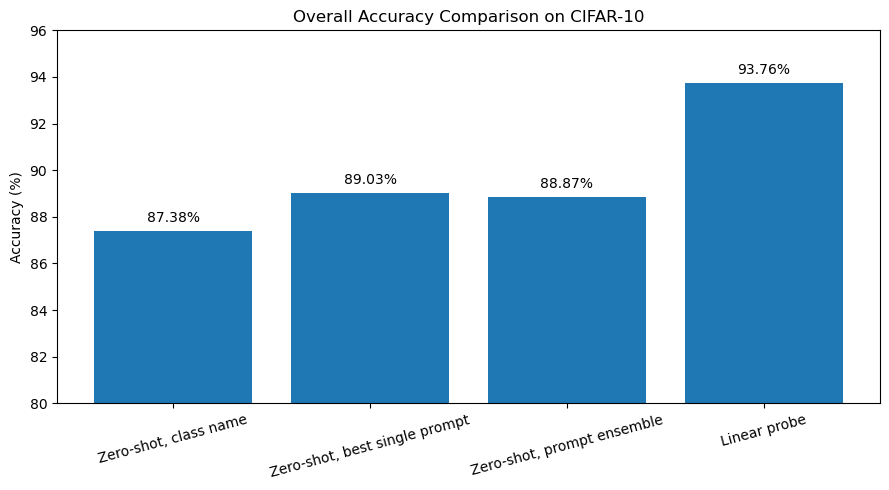

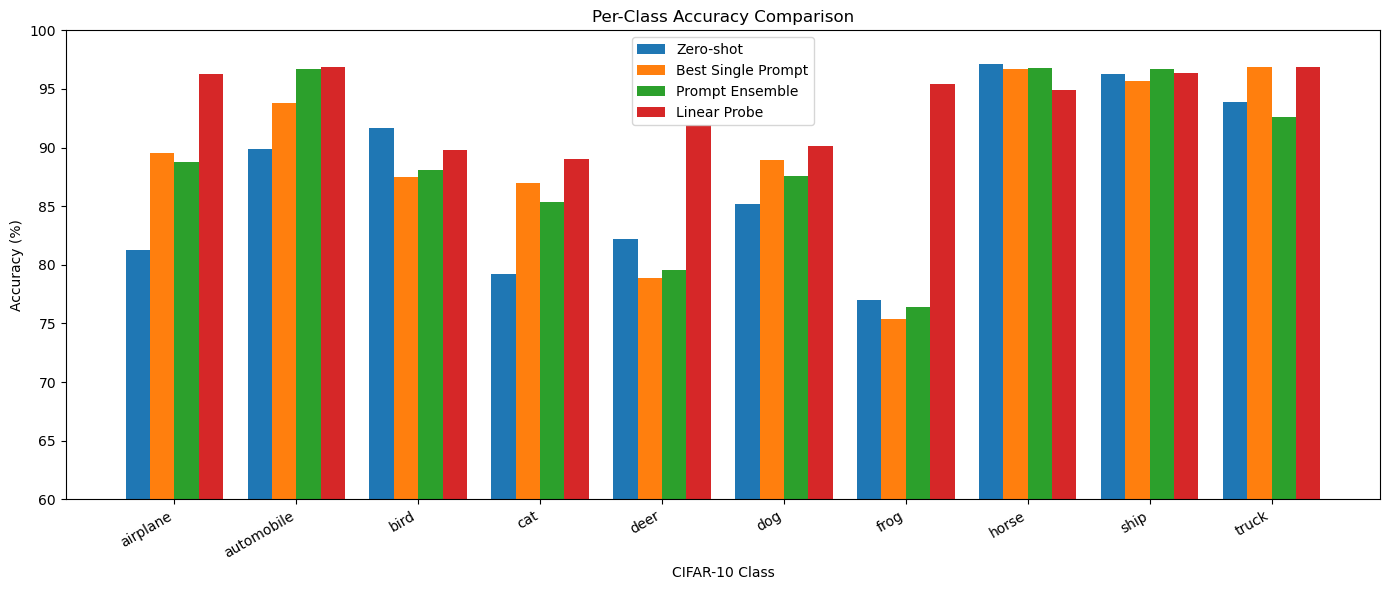

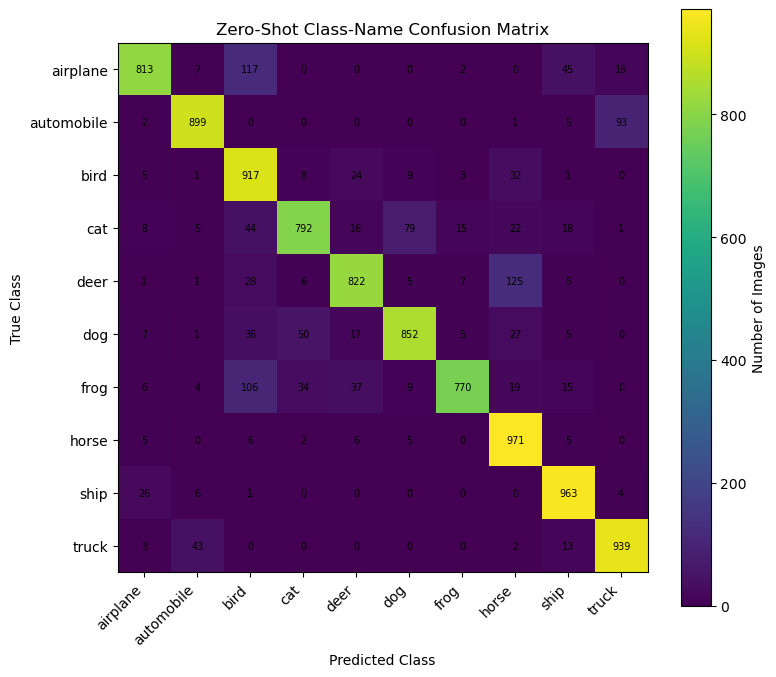

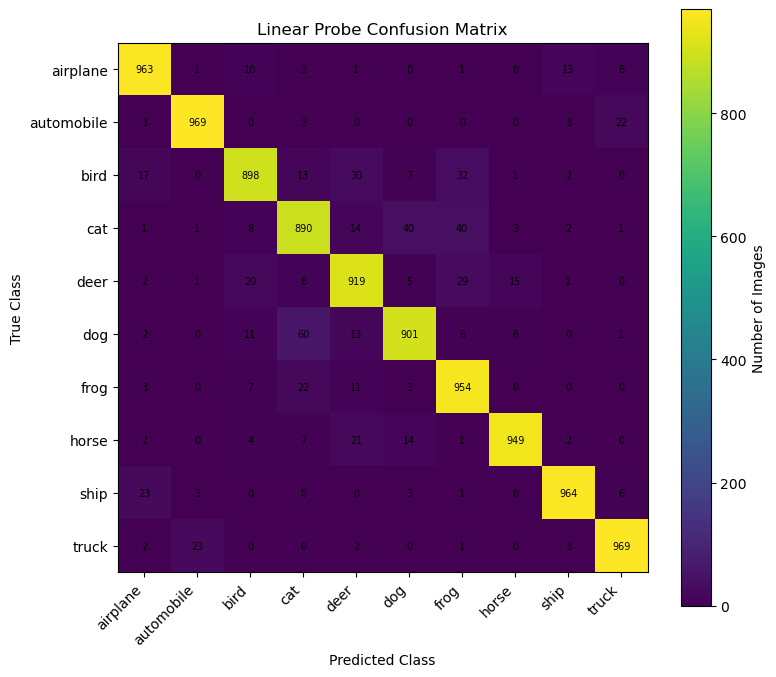

FINAL FIGURES SAVED
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\figures\overall_accuracy_comparison.png
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\figures\per_class_accuracy_comparison.png
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\figures\confusion_matrix_zero_shot.png
D:\Sept\工作\260826-clip-zs-lp-cifar\outputs\figures\confusion_matrix_linear_probe.png


In [8]:
# ============================================================
# Final Analysis — Step 6A
# Generate final experiment visualizations
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

RESULTS_DIR = (
    PROJECT_DIR
    / "outputs"
    / "results"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "outputs"
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 1. Load saved results
# ============================================================

final_comparison_df = pd.read_csv(
    RESULTS_DIR
    / "final_method_comparison.csv"
)

per_class_df = pd.read_csv(
    RESULTS_DIR
    / "final_per_class_comparison.csv"
)

zero_shot_cm = pd.read_csv(
    RESULTS_DIR
    / "confusion_matrix_zero_shot_class_name.csv",
    index_col=0
)

linear_probe_cm = pd.read_csv(
    RESULTS_DIR
    / "confusion_matrix_linear_probe.csv",
    index_col=0
)


# ============================================================
# Figure 1
# Overall accuracy comparison
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.bar(
    final_comparison_df["Setting"],
    final_comparison_df["Accuracy"]
)

ax.set_title(
    "Overall Accuracy Comparison on CIFAR-10"
)

ax.set_ylabel(
    "Accuracy (%)"
)

ax.set_ylim(
    80,
    96
)

ax.tick_params(
    axis="x",
    rotation=15
)

for bar, value in zip(
    bars,
    final_comparison_df["Accuracy"]
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.25,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

overall_fig_path = (
    FIGURES_DIR
    / "overall_accuracy_comparison.png"
)

fig.savefig(
    overall_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Figure 2
# Per-class accuracy comparison
# ============================================================

methods = [
    "ZeroShot_ClassName",
    "Best_Single_Prompt",
    "Prompt_Ensemble",
    "Linear_Probe",
]

method_labels = [
    "Zero-shot",
    "Best Single Prompt",
    "Prompt Ensemble",
    "Linear Probe",
]

x = np.arange(
    len(per_class_df)
)

width = 0.20


fig, ax = plt.subplots(
    figsize=(14, 6)
)

for i, (column, label) in enumerate(
    zip(
        methods,
        method_labels
    )
):

    offset = (
        i - 1.5
    ) * width

    ax.bar(
        x + offset,
        per_class_df[column],
        width,
        label=label
    )


ax.set_title(
    "Per-Class Accuracy Comparison"
)

ax.set_ylabel(
    "Accuracy (%)"
)

ax.set_xlabel(
    "CIFAR-10 Class"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    per_class_df["Class"],
    rotation=30,
    ha="right"
)

ax.set_ylim(
    60,
    100
)

ax.legend()

fig.tight_layout()

per_class_fig_path = (
    FIGURES_DIR
    / "per_class_accuracy_comparison.png"
)

fig.savefig(
    per_class_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Helper function
# Confusion matrix plot
# ============================================================

def plot_confusion_matrix(
    cm_df,
    title,
    save_path
):

    cm = cm_df.to_numpy()

    fig, ax = plt.subplots(
        figsize=(8, 7)
    )

    image = ax.imshow(
        cm
    )

    fig.colorbar(
        image,
        ax=ax,
        label="Number of Images"
    )

    ax.set_title(
        title
    )

    ax.set_xlabel(
        "Predicted Class"
    )

    ax.set_ylabel(
        "True Class"
    )

    ax.set_xticks(
        np.arange(
            len(class_names)
        )
    )

    ax.set_yticks(
        np.arange(
            len(class_names)
        )
    )

    ax.set_xticklabels(
        class_names,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        class_names
    )


    # Show counts in cells
    for i in range(
        len(class_names)
    ):

        for j in range(
            len(class_names)
        ):

            ax.text(
                j,
                i,
                int(cm[i, j]),
                ha="center",
                va="center",
                fontsize=7
            )


    fig.tight_layout()

    fig.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# Figure 3
# Zero-shot confusion matrix
# ============================================================

zero_shot_cm_path = (
    FIGURES_DIR
    / "confusion_matrix_zero_shot.png"
)

plot_confusion_matrix(
    zero_shot_cm,
    "Zero-Shot Class-Name Confusion Matrix",
    zero_shot_cm_path
)


# ============================================================
# Figure 4
# Linear Probe confusion matrix
# ============================================================

linear_probe_cm_fig_path = (
    FIGURES_DIR
    / "confusion_matrix_linear_probe.png"
)

plot_confusion_matrix(
    linear_probe_cm,
    "Linear Probe Confusion Matrix",
    linear_probe_cm_fig_path
)


# ============================================================
# Print saved figure locations
# ============================================================

print("=" * 80)
print("FINAL FIGURES SAVED")
print("=" * 80)

print(overall_fig_path)
print(per_class_fig_path)
print(zero_shot_cm_path)
print(linear_probe_cm_fig_path)

In [9]:
# ============================================================
# Final Analysis — Step 6B
# Final quantitative analysis
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. Zero-shot -> Linear Probe per-class improvement
# ============================================================

final_class_analysis = per_class_df.copy()

final_class_analysis["LP_vs_ZeroShot"] = (
    final_class_analysis["Linear_Probe"]
    - final_class_analysis["ZeroShot_ClassName"]
)

final_class_analysis["LP_vs_BestPrompt"] = (
    final_class_analysis["Linear_Probe"]
    - final_class_analysis["Best_Single_Prompt"]
)

final_class_analysis["LP_vs_Ensemble"] = (
    final_class_analysis["Linear_Probe"]
    - final_class_analysis["Prompt_Ensemble"]
)


final_class_analysis = (
    final_class_analysis
    .sort_values(
        "LP_vs_ZeroShot",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 80)
print("ZERO-SHOT -> LINEAR PROBE: PER-CLASS CHANGE")
print("=" * 80)

for _, row in final_class_analysis.iterrows():

    print(
        f"{row['Class']:<12} "
        f"{row['ZeroShot_ClassName']:>6.2f}% -> "
        f"{row['Linear_Probe']:>6.2f}%   "
        f"({row['LP_vs_ZeroShot']:+.2f} pp)"
    )


# ============================================================
# 2. Helper: extract largest off-diagonal confusion pairs
# ============================================================

def get_top_confusions(
    cm_df,
    class_names,
    top_k=10
):

    cm = cm_df.to_numpy()

    rows = []

    for true_idx in range(len(class_names)):

        for pred_idx in range(len(class_names)):

            if true_idx == pred_idx:
                continue

            rows.append({
                "True_Class": class_names[true_idx],
                "Predicted_Class": class_names[pred_idx],
                "Count": int(
                    cm[true_idx, pred_idx]
                ),
            })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "Count",
            ascending=False
        )
        .head(top_k)
        .reset_index(drop=True)
    )


# ============================================================
# 3. Top Zero-shot confusion pairs
# ============================================================

zero_shot_top_confusions = get_top_confusions(
    zero_shot_cm,
    class_names,
    top_k=10
)

print("\n" + "=" * 80)
print("TOP ZERO-SHOT CONFUSIONS")
print("=" * 80)

display(
    zero_shot_top_confusions
)


# ============================================================
# 4. Top Linear Probe confusion pairs
# ============================================================

linear_probe_top_confusions = get_top_confusions(
    linear_probe_cm,
    class_names,
    top_k=10
)

print("\n" + "=" * 80)
print("TOP LINEAR PROBE CONFUSIONS")
print("=" * 80)

display(
    linear_probe_top_confusions
)


# ============================================================
# 5. Compact final numerical summary
# ============================================================

best_gain_row = final_class_analysis.iloc[0]

worst_gain_row = (
    final_class_analysis
    .sort_values("LP_vs_ZeroShot")
    .iloc[0]
)


print("\n" + "=" * 80)
print("FINAL NUMERICAL SUMMARY")
print("=" * 80)

print(
    f"Overall Zero-shot accuracy : 87.38%"
)

print(
    f"Best single prompt         : 89.03%"
)

print(
    f"Prompt ensemble            : 88.87%"
)

print(
    f"Linear Probe               : 93.76%"
)

print(
    f"\nLinear Probe gain over Zero-shot: "
    f"+6.38 pp"
)

print(
    f"Largest class improvement: "
    f"{best_gain_row['Class']} "
    f"({best_gain_row['LP_vs_ZeroShot']:+.2f} pp)"
)

print(
    f"Smallest / negative improvement: "
    f"{worst_gain_row['Class']} "
    f"({worst_gain_row['LP_vs_ZeroShot']:+.2f} pp)"
)

print(
    "\nLargest Zero-shot confusion:"
)

display(
    zero_shot_top_confusions.head(1)
)

print(
    "Largest Linear Probe confusion:"
)

display(
    linear_probe_top_confusions.head(1)
)


# ============================================================
# 6. Save final analysis tables
# ============================================================

final_class_analysis.to_csv(
    RESULTS_DIR
    / "final_class_level_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

zero_shot_top_confusions.to_csv(
    RESULTS_DIR
    / "top_confusions_zero_shot.csv",
    index=False,
    encoding="utf-8-sig"
)

linear_probe_top_confusions.to_csv(
    RESULTS_DIR
    / "top_confusions_linear_probe.csv",
    index=False,
    encoding="utf-8-sig"
)


print("\nFinal analysis CSV files saved.")

ZERO-SHOT -> LINEAR PROBE: PER-CLASS CHANGE
frog          77.00% ->  95.40%   (+18.40 pp)
airplane      81.30% ->  96.30%   (+15.00 pp)
cat           79.20% ->  89.00%   (+9.80 pp)
deer          82.20% ->  91.90%   (+9.70 pp)
automobile    89.90% ->  96.90%   (+7.00 pp)
dog           85.20% ->  90.10%   (+4.90 pp)
truck         93.90% ->  96.90%   (+3.00 pp)
ship          96.30% ->  96.40%   (+0.10 pp)
bird          91.70% ->  89.80%   (-1.90 pp)
horse         97.10% ->  94.90%   (-2.20 pp)

TOP ZERO-SHOT CONFUSIONS


,True_Class,Predicted_Class,Count
0,deer,horse,125
1,airplane,bird,117
2,frog,bird,106
3,automobile,truck,93
4,cat,dog,79
5,dog,cat,50
6,airplane,ship,45
7,cat,bird,44
8,truck,automobile,43
9,frog,deer,37



TOP LINEAR PROBE CONFUSIONS


,True_Class,Predicted_Class,Count
0,dog,cat,60
1,cat,frog,40
2,cat,dog,40
3,bird,frog,32
4,bird,deer,30
5,deer,frog,29
6,ship,airplane,23
7,truck,automobile,23
8,automobile,truck,22
9,frog,cat,22



FINAL NUMERICAL SUMMARY
Overall Zero-shot accuracy : 87.38%
Best single prompt         : 89.03%
Prompt ensemble            : 88.87%
Linear Probe               : 93.76%

Linear Probe gain over Zero-shot: +6.38 pp
Largest class improvement: frog (+18.40 pp)
Smallest / negative improvement: horse (-2.20 pp)

Largest Zero-shot confusion:


,True_Class,Predicted_Class,Count
0,deer,horse,125


Largest Linear Probe confusion:


,True_Class,Predicted_Class,Count
0,dog,cat,60



Final analysis CSV files saved.
